In [1]:
# Distinctness gate, same switch as forming_n_gram_datasets_ACE.ipynb:
#   True  = legacy gated dataset; False = ungated (_gate_false files)
APPLY_DISTINCTNESS_GATE = False
GATE_SUFFIX = '' if APPLY_DISTINCTNESS_GATE else '_gate_false'


def normalize_style(style):
    s = style
    if s in ["Even 8th's", "Even 8's"]:
        return 'Even 8ths'
    if 'Swing' in s or 'Fusion' in s or 'Jazz' in s:
        return 'Jazz'
    if 'Blues' in s:
        return 'Blues'
    if 'Folk' in s:
        return 'Folk'
    if 'Bossa' in s:
        return 'Bossa'
    if 'Reggae' in s:
        return 'Reggae'
    if 'Samba' in s:
        return 'Samba'
    if 'Funk' in s:
        return 'Funk'
    if 'Pop' in s:
        return 'Pop'
    if 'Son' in s:
        return 'Son'
    if 'Rock' in s or s == 'Beatles':
        return 'Rock'
    if 'Soul' in s:
        return 'Soul'
    if 'Balad' in s:
        return 'Balad'
    if s == "R'n'B":
        return "RnB"
    if s == 'Afoxe':
        return 'Afoxé'
    if s in ['Worship', 'Traditional Gospel']:
        return 'Gospel'
    if s == 'Even 8ths':
        return 'Pop'
    return s

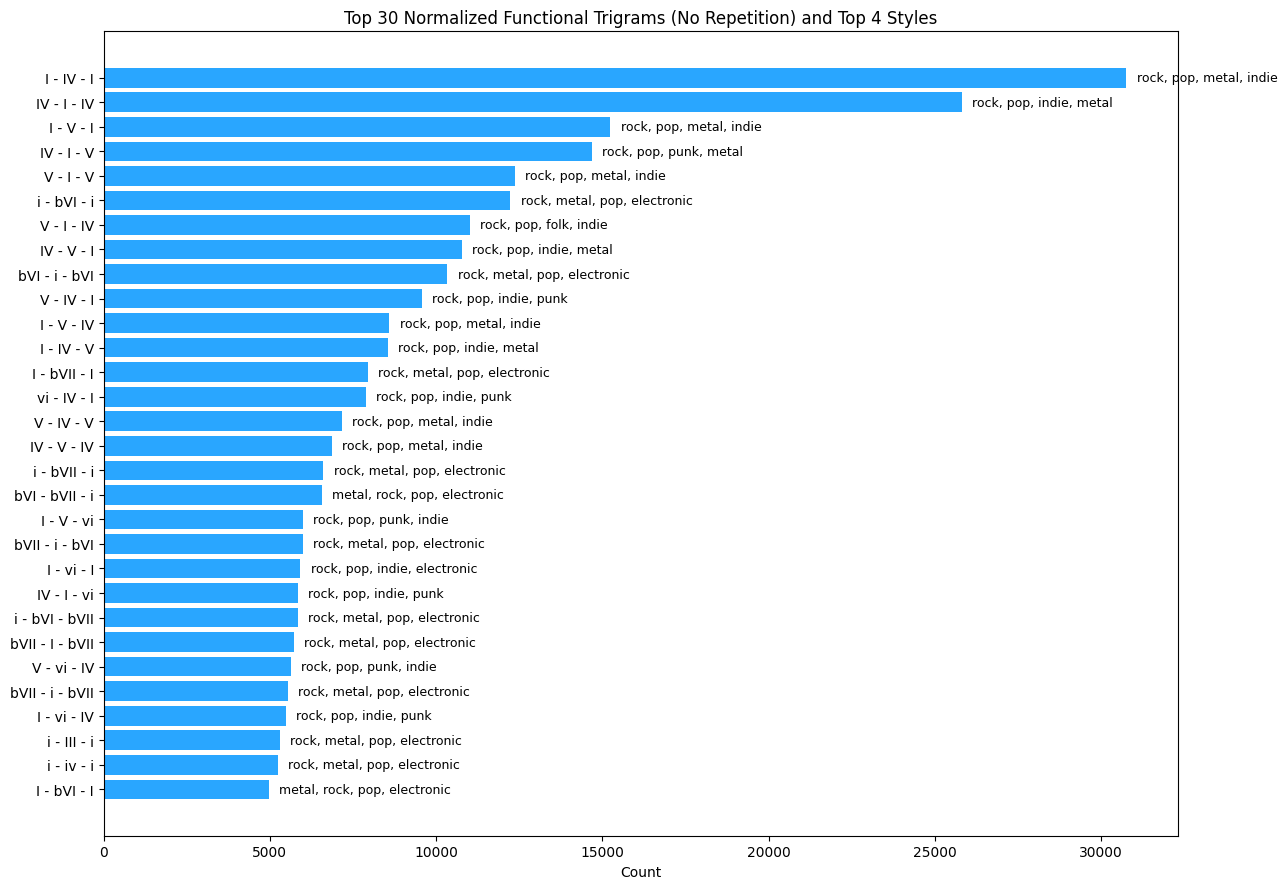

In [2]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

def normalize_function_label(label):
    # Remove accidentals, extensions, and alterations: keep only Roman numerals and accidentals at start
    match = re.match(r"([b#♭♯]*[IViv]+)", label)
    return match.group(1) if match else label

def normalize_trigram(function_trigram):
    # Return canonicalized tuple of roman numerals
    return tuple(normalize_function_label(x) for x in function_trigram)

# Load data
with open(f'/workspace/ngram_datasets/trigrams/3gram_dataset_lastfm_ace{GATE_SUFFIX}.json', 'r') as f:
    data = json.load(f)

# Aggregate: trigram -> count, style counter
trigram_count = Counter()
trigram_styles = defaultdict(Counter)

for entry in data:
    func_trigram = normalize_trigram(entry['ngram'])
    if len(set(func_trigram)) == 1:
        continue
    count = entry['count']
    for style, scount in entry.get('human_styles', []):
        norm_style = normalize_style(style)
        trigram_styles[func_trigram][norm_style] += scount
    trigram_count[func_trigram] += count

# Select top 
selected = 30
top_trigrams = trigram_count.most_common(selected)

# Prepare for plotting
plot_labels = []
plot_counts = []
plot_topstyles = []

num_styles = 4
for trigram, count in top_trigrams:
    roman_label = ' - '.join(trigram)
    styles_counter = trigram_styles[trigram]
    top_n_styles = [s for s, _ in styles_counter.most_common(num_styles)]
    plot_labels.append(roman_label)
    plot_counts.append(count)
    plot_topstyles.append(', '.join(top_n_styles))

# Reverse for horizontal plot (most common at top)
plot_labels = plot_labels[::-1]
plot_counts = plot_counts[::-1]
plot_topstyles = plot_topstyles[::-1]

# Plot
fig, ax = plt.subplots(figsize=(13, 9))
bars = ax.barh(plot_labels, plot_counts, color="#29a6ff")

for i, (c, styles) in enumerate(zip(plot_counts, plot_topstyles)):
    ax.text(c + max(plot_counts) * 0.01, i, styles, va='center', fontsize=9, color="#000000")

ax.set_xlabel('Count')
ax.set_title(f'Top {selected} Normalized Functional Trigrams (No Repetition) and Top {num_styles} Styles')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1071885/2037479474.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=text_size)
/tmp/ipykernel_1071885/2037479474.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)


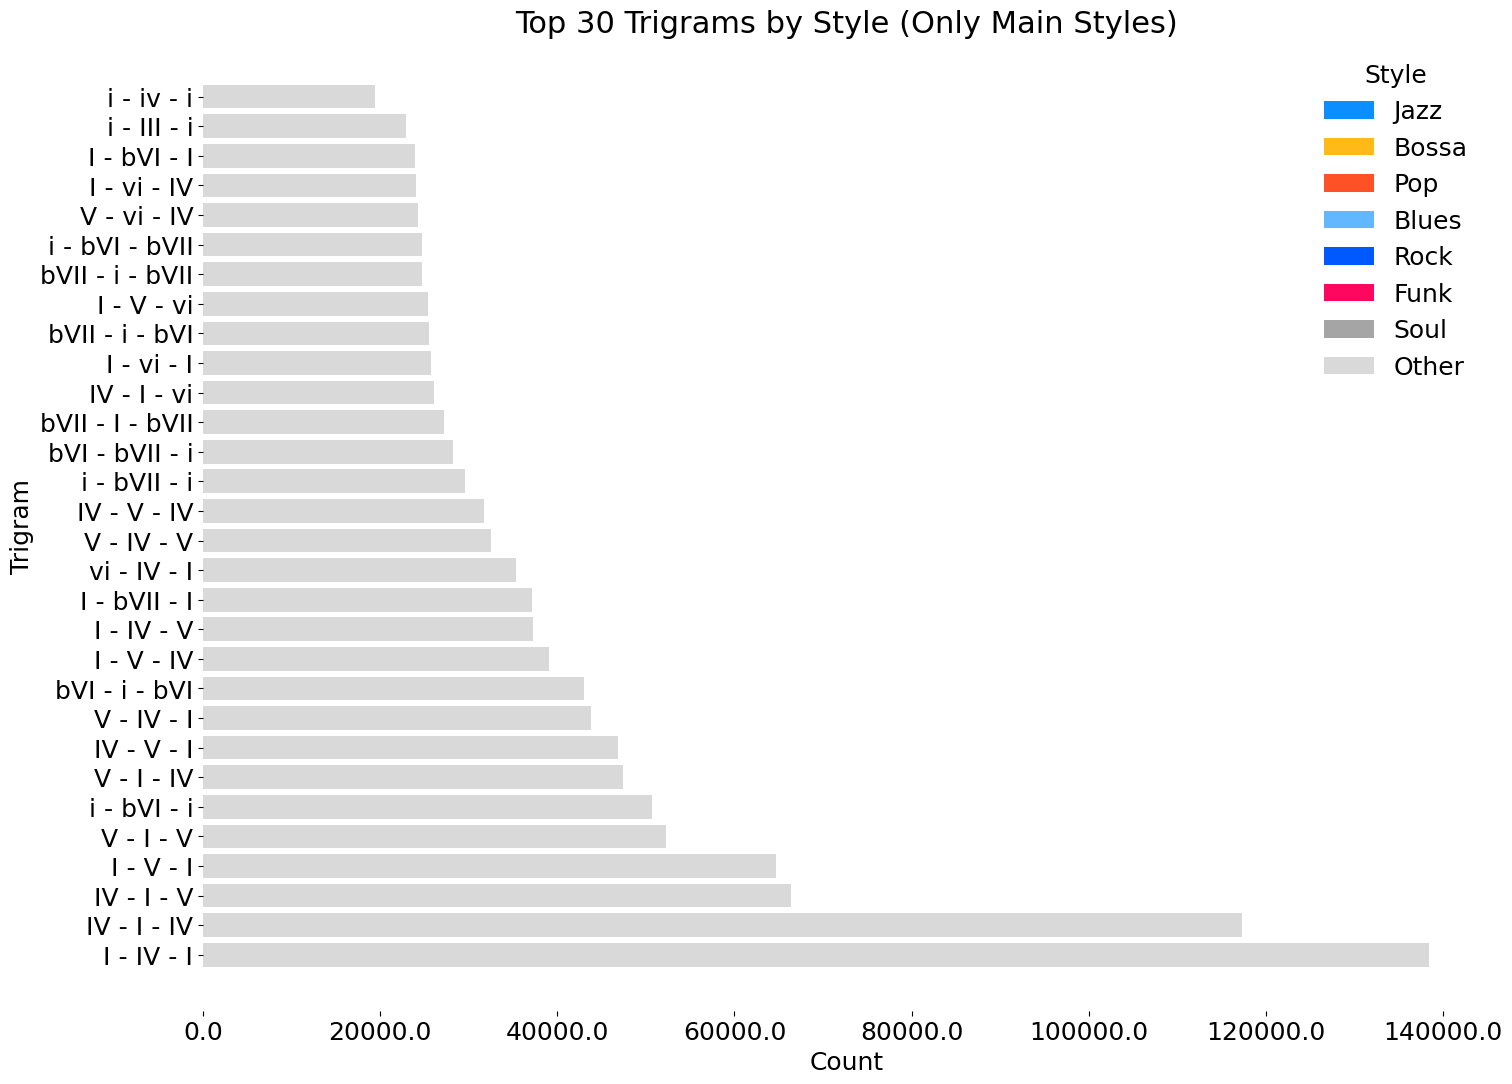

In [3]:
import numpy as np
import matplotlib.pyplot as plt

N = 30
chosen_styles = ['Jazz', 'Bossa', 'Pop', 'Blues', 'Rock', 'Funk', 'Soul']

# Get top N trigrams
top_trigrams = sorted(trigram_count.items(), key=lambda x: x[1], reverse=True)[:N]
labels = [' - '.join(trigram) for trigram, _ in top_trigrams]

# Build the data matrix and compute total counts for sorting
data = []
totals = []
for trigram, _ in top_trigrams:
    style_counts = trigram_styles[trigram]
    row = [style_counts.get(style, 0) for style in chosen_styles]
    other_count = sum(v for k, v in style_counts.items() if k not in chosen_styles)
    row.append(other_count)
    data.append(row)
    totals.append(sum(row))
data = np.array(data)

# Sort by total count (descending)
sorted_idx = np.argsort(totals)[::-1]
data = data[sorted_idx]
labels = [labels[i] for i in sorted_idx]

# Custom colors for these genres
custom_palette = {
    'Jazz': "#0c8eff",
    'Bossa': "#ffba18",
    'Pop': "#ff5125",
    'Blues': "#61b8ff",
    'Rock': "#0059ff",
    'Funk': "#ff075e",
    'Soul': "#a5a5a5",
    'Other': "#d9d9d9",
}
bar_colors = [custom_palette.get(style, '#636e72') for style in chosen_styles + ['Other']]

# Plot
fig, ax = plt.subplots(figsize=(15, 10))
left = np.zeros(len(labels))
for i, (style, color) in enumerate(zip(chosen_styles + ['Other'], bar_colors)):
    ax.barh(labels, data[:, i], left=left, label=style, color=color)
    left += data[:, i]

# Remove frame
for spine in ax.spines.values():
    spine.set_visible(False)
text_size = 18
# Set bigger font sizes
ax.set_xlabel('Count', fontsize=text_size)
ax.set_ylabel('Trigram', fontsize=text_size)
ax.set_title(f'Top {N} Trigrams by Style (Only Main Styles)', fontsize=22)
ax.set_yticklabels(labels, fontsize=text_size)
ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)

# Legend with bigger font
ax.legend(title='Style', fontsize=text_size, title_fontsize=text_size, loc='upper right', frameon=False)

plt.tight_layout(pad=0.1)
plt.subplots_adjust(bottom=0.01, top=0.98)
plt.show()



In [4]:
import re

def split_function_label(label):
    match = re.match(r"^([b#♭♯]*[IViv]+)(.*)$", label)
    if match:
        degree = match.group(1)
        extension = match.group(2)
        return degree, extension
    else:
        return label, ""

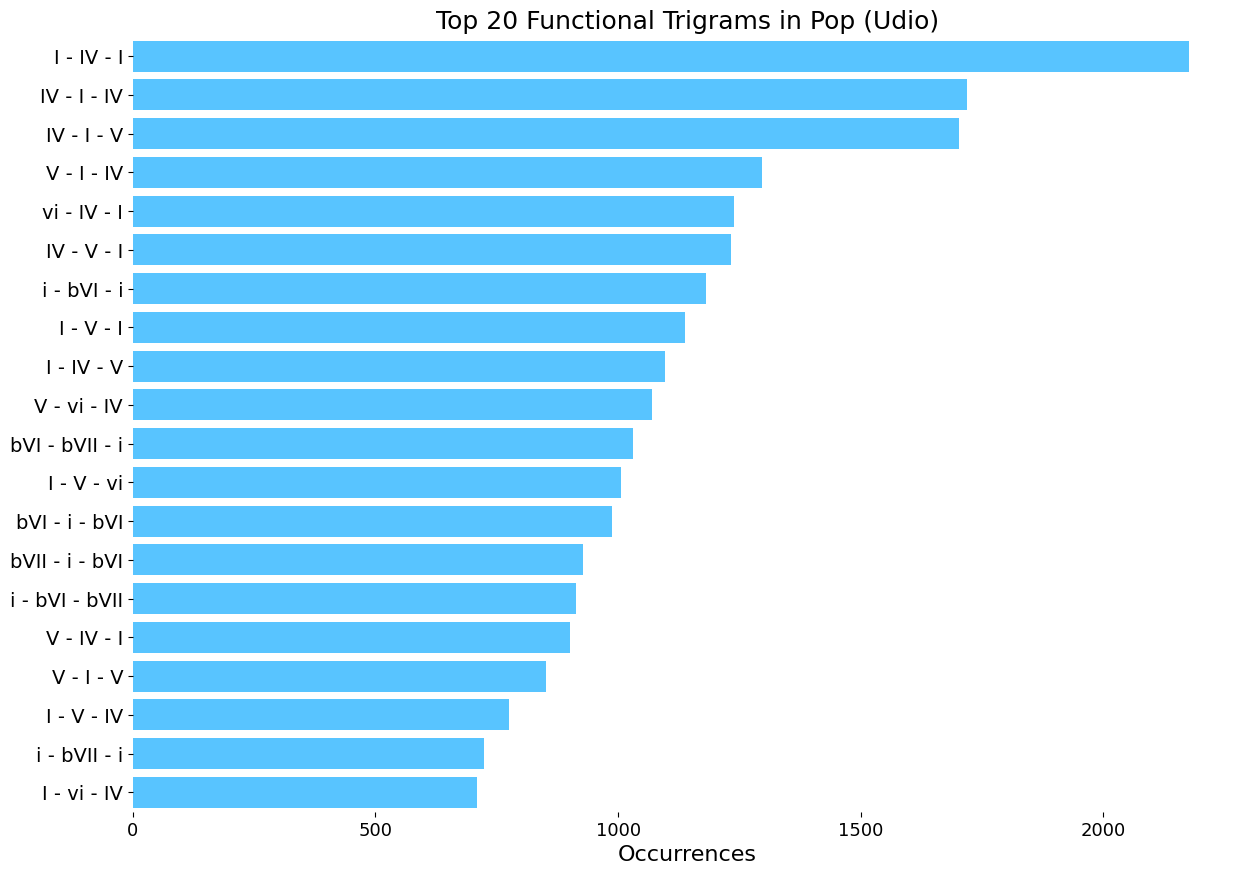

In [5]:
import json
import matplotlib.pyplot as plt

collection = 'udio'
path = f'/workspace/ngram_datasets/trigrams/3gram_dataset_{collection}_ace{GATE_SUFFIX}.json'
# Load the data
with open(path, 'r') as f:
    data = json.load(f)

# Extract trigrams with Pop in styles, and get their Pop count
pop_trigrams = []
style = 'pop'
for entry in data:
    for s, count in entry['dortmund_genres']:
        if s == style:
            pop_trigrams.append({
                "function": entry['ngram'],
                "pop_count": count
            })
            break

N = 20
# Sort by Pop count, descending
pop_trigrams = sorted(pop_trigrams, key=lambda x: x['pop_count'], reverse=True)[:N]

# Prepare data for plotting
labels = [' - '.join(tri['function']) for tri in pop_trigrams]
counts = [tri['pop_count'] for tri in pop_trigrams]

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(labels[::-1], counts[::-1], color="#58c4ff")

# Remove all spines (the box/frame)
for spine in ax.spines.values():
    spine.set_visible(False)

# Tighten layout
plt.tight_layout(pad=0.05)

# Set y-limits to crop empty space
ax.set_ylim(-0.5, len(labels) - 0.5)  # Half-bar padding

ax.set_xlabel('Occurrences', fontsize=16)
ax.set_title('Top 20 Functional Trigrams in {} ({})'.format(style.capitalize(), collection.capitalize()), fontsize=18)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=13)

plt.show()

In [6]:
from trigram_search import query_trigram_usage

result = query_trigram_usage(["ii", "V", "I"])
print(result)


{'functional_trigrams': {'count': 4620, 'styles': [['Jazz', 18241], ['Pop', 4641], ['Bossa', 4151], ['Samba', 4031], ['Ballad', 4030], ['Latin', 3201], ['Waltz', 3197], ['Bolero', 1814], ['Gospel', 1619], ['Funk', 1597]], 'matched': 'exact', 'function': ['ii', 'V', 'I']}, 'trigram_dataset': {'total_count': 10298, 'styles': [('Medium Swing', 8565), ('Ballad', 8160), ('Samba', 6991), ('Medium Up Swing', 6639), ('Up Tempo Swing', 6534), ('Waltz', 6392), ('Bossa Nova', 6231), ('Slow Swing', 5713), ('Latin', 5194), ('Even 8ths', 2645)], 'composers': [('Richard Rodgers', 5151), ('Harold Arlen', 5005), ('Cole Porter', 4630), ('George Gershwin', 4550), ('Duke Ellington', 4444), ('Exercise', 4430), ('Antonio-Carlos Jobim', 4319), ('Jimmy Van-Heusen', 4199), ('Hoagy Carmichael', 3941), ('Frank Loesser', 3886)]}}


{'functional_trigrams': {'count': 674, 'styles': [['Pop', 680], ['Samba', 441], ['Rock', 403], ['Jazz', 270], ['Soul', 150], ['Gospel', 137], ['Folk', 123], ['Ballad', 103], ['Blues', 102], ['Latin', 82]], 'matched': 'exact', 'function': ['IV', 'V', 'I']}, 'trigram_dataset': {'total_count': 1817, 'styles': [('Samba', 924), ('Medium Swing', 642), ('Ballad', 462), ('Samba Enredo', 407), ('Rock Pop', 395), ('Rock', 357), ('Pop', 308), ('Up Tempo Swing', 226), ('Latin', 209), ('Waltz', 203)], 'composers': [('The Beatles (Lennon, McCartney)', 295), ('Nelson Cavaquinho', 276), ('Zeca Pagodinho', 235), ('Fundo de Quintal', 218), ('Roberto Ribeiro', 184), ('Gonzaguinha', 173), ('João Nogueira', 171), ('Martinho da Vila', 160), ('Chico Buarque', 149), ('GRES Salgueiro 2010', 146)]}}


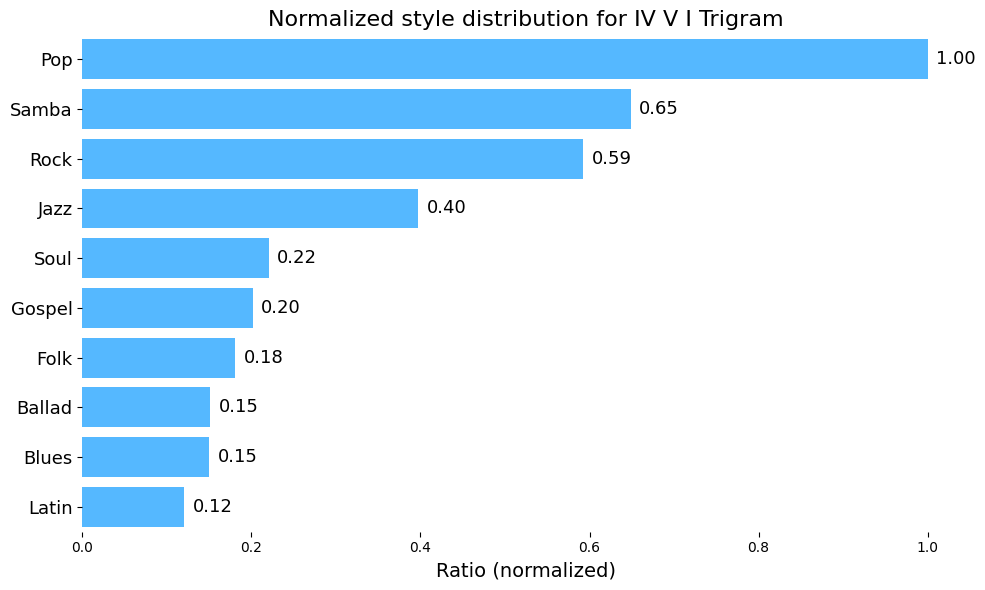

In [7]:
import matplotlib.pyplot as plt

find = ["IV", "V", "I"]

result = query_trigram_usage(find)

print(result)

styles_counts = result["functional_trigrams"]["styles"]
if not styles_counts:
    print("No styles to plot.")
else:
    labels, counts = zip(*styles_counts)
    counts = list(counts)
    max_count = max(counts)
    norm_counts = [c / max_count for c in counts]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(labels[::-1], norm_counts[::-1], color="#55b8ff", edgecolor="none")

    # Remove frame
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_ylim(-0.5, len(labels) - 0.5)

    # Add ratio labels
    for bar in bars:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.2f}", va='center', fontsize=13)

    ax.set_xlabel("Ratio (normalized)", fontsize=14)
    ax.set_title('Normalized style distribution for ' + ' '.join(find) + ' Trigram', fontsize=16)
    ax.tick_params(axis='y', labelsize=13)
    plt.tight_layout()
    plt.show()


In [8]:
import json
from collections import Counter

type = "suno"
path = f"/workspace/ngram_datasets/trigrams/3gram_dataset_{type}_ace{GATE_SUFFIX}.json"

with open(path) as f:
    trigram_data = json.load(f)

genre_counter = Counter()

for entry in trigram_data:
    # entry['genres'] is a list of [genre, weight]
    for genre, weight in entry.get('genres', []):
        genre_counter[genre] += weight

# Print top N genres
N = 30
print("Most common Dortmund genres in", type, "trigrams:")
for genre, weight in genre_counter.most_common(N):
    print(f"{genre:15} {weight:.2f}")


Most common Dortmund genres in suno trigrams:


In [9]:
from collections import defaultdict
import numpy as np

N = 30
# Include 'pop' and any other Dortmund genres you care about
chosen_styles = ['rock', 'electronic', 'jazz', 'pop', 'alternative', 'raphiphop', 'folkcountry', 'funksoulrnb', 'blues']

trigram_count = {}
trigram_genres = defaultdict(dict)

for entry in trigram_data:
    trigram = tuple(entry['ngram'])
    count = entry['count']
    trigram_count[trigram] = count
    # genres is a list of [genre, float sum]
    genre_counts = {k.lower(): v for k, v in entry['dortmund_genres']}  # always lowercase for safety
    trigram_genres[trigram] = genre_counts

# Get top N trigrams by total count
top_trigrams = sorted(trigram_count.items(), key=lambda x: x[1], reverse=True)[:N]
labels = [' - '.join(trigram) for trigram, _ in top_trigrams]

# Build data matrix (main genres + 'other')
data = []
totals = []
for trigram, _ in top_trigrams:
    genre_counts = trigram_genres[trigram]
    row = [genre_counts.get(style, 0) for style in chosen_styles]
    # "other" is sum of all dormund genres not in chosen_styles
    other_count = sum(v for k, v in genre_counts.items() if k not in chosen_styles)
    row.append(other_count)
    data.append(row)
    totals.append(sum(row))
data = np.array(data)

# Sort by total count (descending) (this actually does nothing since already sorted)
sorted_idx = np.argsort(totals)[::-1]
data = data[sorted_idx]
labels = [labels[i] for i in sorted_idx]


/tmp/ipykernel_1071885/1333933885.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=text_size)
/tmp/ipykernel_1071885/1333933885.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)


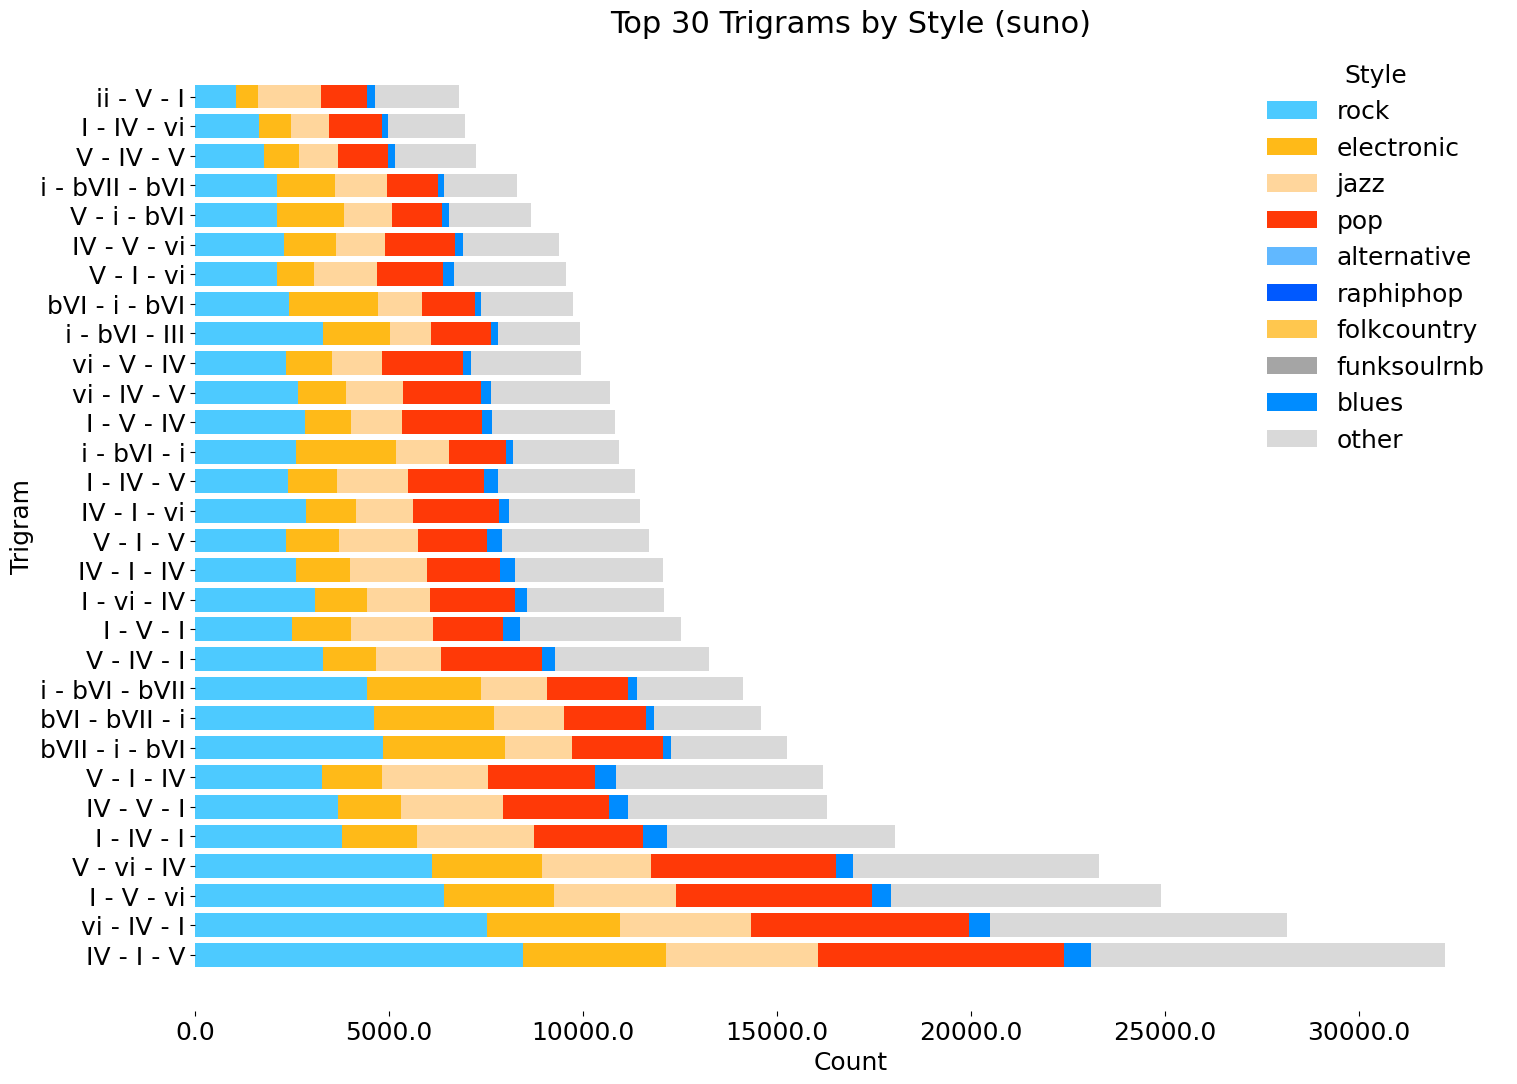

In [10]:
import matplotlib.pyplot as plt


custom_palette = {
    'rock': "#4dcaff",
    'electronic': "#ffba18",
    'jazz': "#ffd69c",
    'pop': "#ff3907",
    'alternative': "#61b8ff",
    'raphiphop': "#0059ff",
    'folkcountry': "#ffc74e",
    'funksoulrnb': "#a5a5a5",
    'blues': "#008cff",
    'other': "#d9d9d9",
}
bar_colors = [custom_palette.get(style, '#636e72') for style in chosen_styles + ['other']]

fig, ax = plt.subplots(figsize=(15, 10))
left = np.zeros(len(labels))
for i, (style, color) in enumerate(zip(chosen_styles + ['other'], bar_colors)):
    ax.barh(labels, data[:, i], left=left, label=style, color=color)
    left += data[:, i]

for spine in ax.spines.values():
    spine.set_visible(False)
text_size = 18
ax.set_xlabel('Count', fontsize=text_size)
ax.set_ylabel('Trigram', fontsize=text_size)
ax.set_title(f'Top {N} Trigrams by Style ({type})', fontsize=22)
ax.set_yticklabels(labels, fontsize=text_size)
ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)
ax.legend(title='Style', fontsize=text_size, title_fontsize=text_size, loc='upper right', frameon=False)

plt.tight_layout(pad=0.1)
plt.subplots_adjust(bottom=0.01, top=0.98)
plt.show()


/tmp/ipykernel_1071885/898765334.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{t/total_overall:.1%}' for t in ticks], fontsize=text_size)


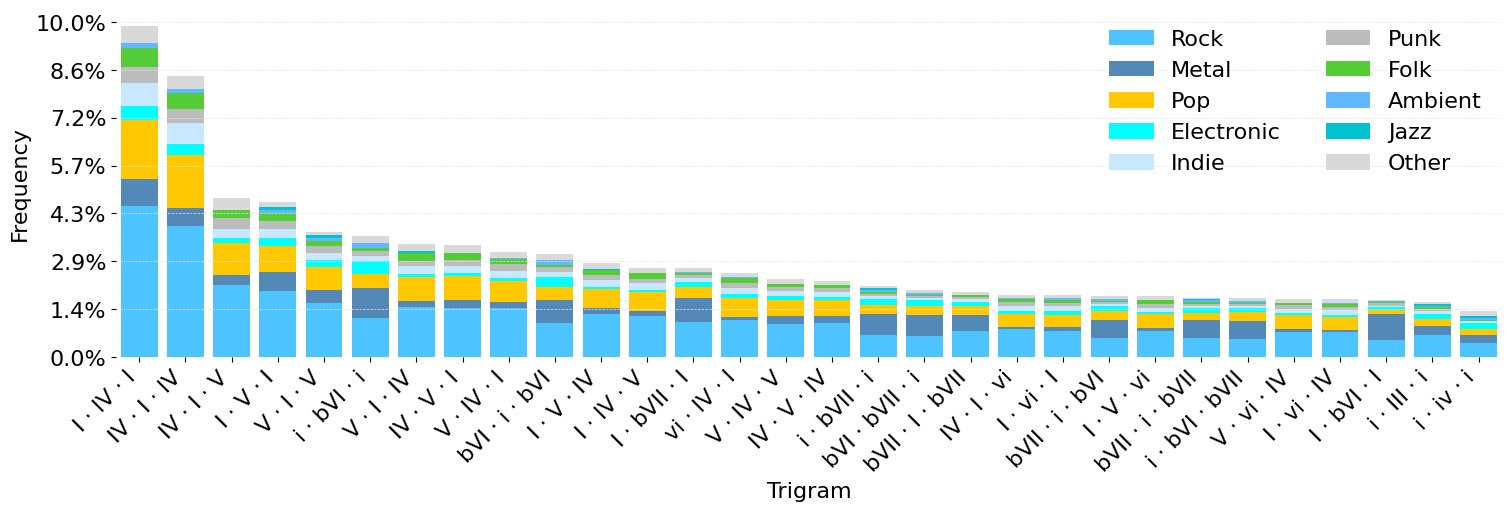

saved ../Figures/01_lastfm_top_30_ace_gate_false.png


/tmp/ipykernel_1071885/898765334.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{t/total_overall:.1%}' for t in ticks], fontsize=text_size)


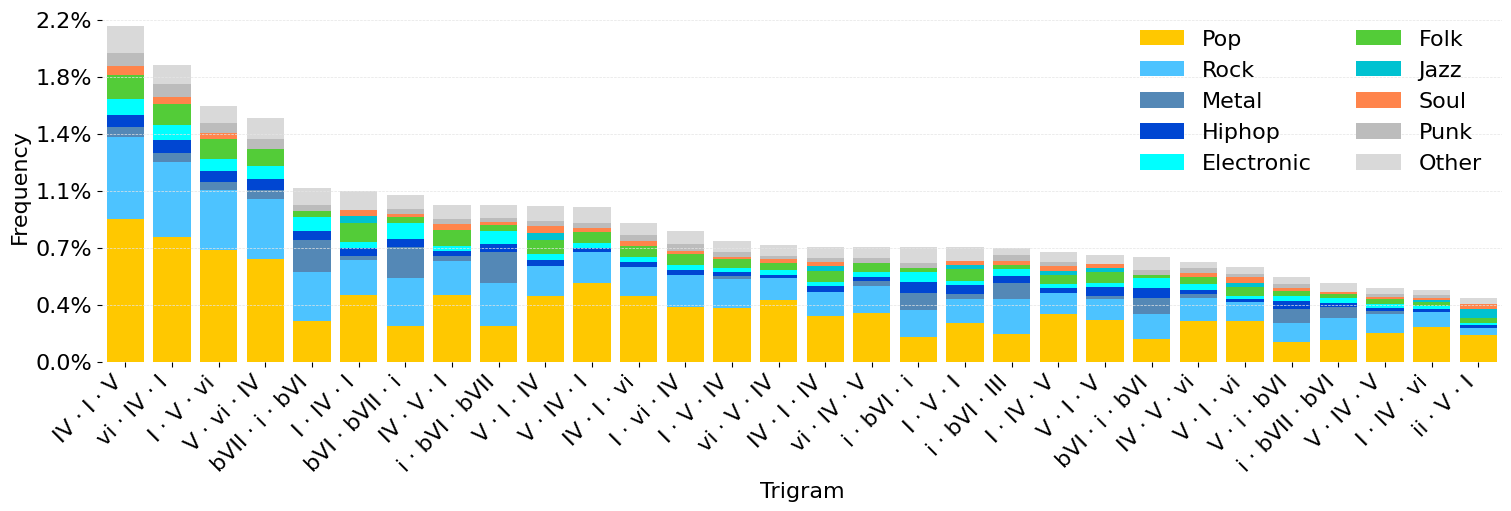

saved ../Figures/02_suno_top_30_ace_gate_false.png


/tmp/ipykernel_1071885/898765334.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{t/total_overall:.1%}' for t in ticks], fontsize=text_size)


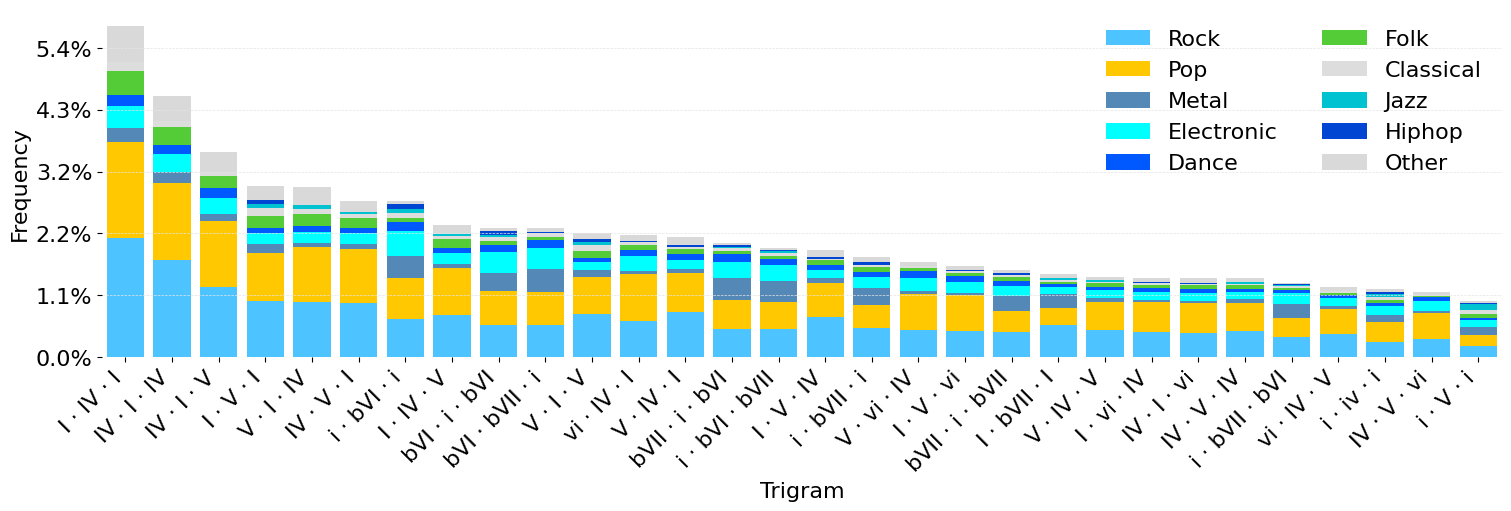

saved ../Figures/03_udio_top_30_ace_gate_false.png


In [11]:
import json
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import json

collection = ["lastfm", "suno", "udio"]
id = 1
for type in collection:
    path = f"/workspace/ngram_datasets/trigrams/3gram_dataset_{type}_ace{GATE_SUFFIX}.json"

    with open(path) as f:
        trigram_data = json.load(f)

    # Build all_styles
    all_styles = Counter()
    for entry in trigram_data:
        for style, count in entry.get('human_styles', []):
            all_styles[style.lower()] += count

    N_styles = 9  # top N
    chosen_styles = [s for s, _ in all_styles.most_common(N_styles)]

    custom_palette = {
        'pop':      "#FFC800",
        'rock':     "#4DC3FF",
        'electronic': "#00FFFF",
        'hiphop':   "#0046D2",
        'country':  "#FB9530",
        'ambient':  "#61B8FF",
        'metal':    "#5488B6",
        'punk':     "#BCBCBC",
        'soul':     "#FF844B",
        'dance':    "#0059FF",
        'folk':     "#53CC38",
        'funk':     "#ACDEFF",
        'blues':    "#69E1FF",
        'jazz':     "#00C2D1",
        'rnb':      "#FF7C40",
        'indie' :   "#C8E8FF",
        'other':    "#d9d9d9",
    }

    all_plot_styles = chosen_styles + ['other']
    bar_colors = [custom_palette.get(style, "#dddddd") for style in all_plot_styles]

    # (Rest of your matrix-building and plotting code—unchanged)
    trigram_count = {}
    trigram_styles = defaultdict(dict)

    for entry in trigram_data:
        trigram = tuple(entry['ngram'])
        count = entry['count']
        trigram_count[trigram] = count
        style_counts = {k.lower(): v for k, v in entry['human_styles']}
        trigram_styles[trigram] = style_counts

    N = 30
    top_trigrams = sorted(trigram_count.items(), key=lambda x: x[1], reverse=True)[:N]
    labels = [' · '.join(trigram) for trigram, _ in top_trigrams]

    data = []
    totals = []
    for trigram, _ in top_trigrams:
        style_counts = trigram_styles[trigram]
        row = [style_counts.get(style, 0) for style in chosen_styles]
        other_count = sum(v for k, v in style_counts.items() if k not in chosen_styles)
        row.append(other_count)
        data.append(row)
        totals.append(sum(row))
    data = np.array(data)
    sorted_idx = np.argsort(totals)[::-1]
    data = data[sorted_idx]
    labels = [labels[i] for i in sorted_idx]

    fig, ax = plt.subplots(figsize=(15, 5))     # wider than tall

    bottom = np.zeros(len(labels))              # where each stacked segment starts
    for style, color, column in zip(all_plot_styles, bar_colors, data.T):
        ax.bar(labels, column, bottom=bottom,    # <-- vertical stacked bars
            label=style.capitalize(), color=color)
        bottom += column

    total_overall = sum(trigram_count.values()) 
    ticks = ax.get_yticks()
    text_size = 16
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    ax.grid(axis='y',                      # only horizontal lines
        linestyle='--',                # dashed
        linewidth=0.5,
        color="#e5e5e5",
        alpha=1.0) 

    ax.set_xlabel('Trigram', fontsize=text_size)
    ax.set_ylabel('Frequency',   fontsize=text_size)
    # ax.set_title(f'Top {N} Trigrams by Style ({type.capitalize()})', fontsize=text_size, pad=10)
    
    ax.set_xlim(-0.5, len(labels) - 0.5)
    # rotate long trigram labels so they fit
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=text_size)

    # show counts in thousands on y-axis, if you like
    # 1 decimal place avoids repeated tick labels for collections with small y-range (e.g. Suno)
    ax.set_yticklabels([f'{t/total_overall:.1%}' for t in ticks], fontsize=text_size)
    ax.margins(x=0) 
    
    ax.legend(fontsize=text_size, frameon=False, ncol=len(all_plot_styles)//4)
    plt.tight_layout(pad=0.3)
    plt.show()
    out_name = f"{id:02d}_{type}_top_30_ace{GATE_SUFFIX}.png"   # 01_lastfm_top_30_ace.png, …
    path = f"../Figures/{out_name}"
    fig.savefig(path, dpi=300, bbox_inches='tight')  # high-res, trimmed
    print(f"saved {path}")
    id += 1


In [2]:
# Dynamically extract top trigrams from Suno ACE data (no hardcoding!)
import json
from collections import Counter

# --- Relative-minor normalization ---
# Collapse Aeolian-cadence trigrams into their relative-major equivalents.
# i-bVI-III  → vi-IV-I   (Am-F-C in Am = vi-IV-I in C major)
# i-bVI-bVII → vi-IV-V   (Am-F-G in Am = vi-IV-V in C major)
# bVII-i-bVI → V-vi-IV   (rotation)
# bVI-bVII-i → IV-V-vi   (rotation)
RM_MAP = {
    ('i', 'bVI', 'III'):  ('vi', 'IV', 'I'),
    ('i', 'bVI', 'bVII'): ('vi', 'IV', 'V'),
    ('bVII', 'i', 'bVI'): ('V', 'vi', 'IV'),
    ('bVI', 'bVII', 'i'): ('IV', 'V', 'vi'),
}

def to_relative_major(trigram):
    """Convert ONLY the hardcoded Aeolian-cadence trigram(s).
    Returns (normalized_trigram, was_converted)."""
    tri = tuple(trigram)
    if tri in RM_MAP:
        return RM_MAP[tri], True
    return tri, False

with open(f"/workspace/ngram_datasets/trigrams/3gram_dataset_suno_ace{GATE_SUFFIX}.json") as f:
    suno_data = json.load(f)

suno_trigram_counts = Counter()
rm_contributions = Counter()   # counts absorbed from relative-minor spelling

for entry in suno_data:
    raw = tuple(entry['ngram'])
    norm, was_minor = to_relative_major(raw)
    suno_trigram_counts[norm] += entry['count']
    if was_minor:
        rm_contributions[norm] += entry['count']

# Top N most frequent Suno trigrams as targets
N_TARGETS = 20
trigram_targets = [tri for tri, _ in suno_trigram_counts.most_common(N_TARGETS)]

# Tag (RM) only those targets that actually absorbed minor-spelling counts
rm_trigrams = {tri for tri in trigram_targets if rm_contributions.get(tri, 0) > 0}

print(f"Top {N_TARGETS} Suno ACE trigrams (RM = absorbed Aeolian-cadence counts):")
for i, tri in enumerate(trigram_targets, 1):
    rm_tag = "" if tri in rm_trigrams else ""
    rm_n = rm_contributions.get(tri, 0)
    total_n = suno_trigram_counts[tri]
    rm_pct = rm_n / total_n * 100 if total_n else 0
    print(f"  {i:2d}. {' - '.join(tri):20s}  ({total_n:,}){rm_tag}"
          + (f"  [{rm_n:,} = {rm_pct:.1f}% from minor spelling]" if rm_n else ""))

# Include all rotations
all_target_trigrams = set()
for tri in trigram_targets:
    for i in range(3):
        all_target_trigrams.add(tuple(list(tri[i:]) + list(tri[:i])))

Top 20 Suno ACE trigrams (RM = absorbed Aeolian-cadence counts):
   1. V - vi - IV           (40,007)  [16,103 = 40.3% from minor spelling]
   2. vi - IV - I           (39,031)  [10,251 = 26.3% from minor spelling]
   3. IV - I - V            (32,875)
   4. vi - IV - V           (25,877)  [14,947 = 57.8% from minor spelling]
   5. I - V - vi            (25,364)
   6. IV - V - vi           (25,068)  [15,389 = 61.4% from minor spelling]
   7. I - IV - I            (18,433)
   8. V - I - IV            (16,506)
   9. IV - V - I            (16,454)
  10. V - IV - I            (13,468)
  11. I - V - I             (12,753)
  12. I - vi - IV           (12,318)
  13. IV - I - IV           (12,301)
  14. V - I - V             (11,858)
  15. IV - I - vi           (11,761)
  16. I - IV - V            (11,486)
  17. i - bVI - i           (11,436)
  18. I - V - IV            (10,987)
  19. bVI - i - bVI         (10,219)
  20. vi - V - IV           (10,190)


In [13]:
from collections import defaultdict, Counter
import json

collections = ['lastfm', 'suno', 'udio']
style_collection_trigram_counts = defaultdict(lambda: defaultdict(Counter))
total_style_collection_counts = defaultdict(lambda: defaultdict(int))

# Count for each collection
for collection in collections:
    with open(f"../ngram_datasets/trigrams/3gram_dataset_{collection}_ace{GATE_SUFFIX}.json") as f:
        trigram_data = json.load(f)
    for entry in trigram_data:
        trigram, _ = to_relative_major(tuple(entry['ngram']))
        style_counts = entry.get('human_styles', [])
        if trigram in all_target_trigrams:
            for style, count in style_counts:
                style_collection_trigram_counts[trigram][collection][style] += count
        for style, count in style_counts:
            total_style_collection_counts[collection][style] += count

# (rest of your code: enrichment, Fisher's test, results, DataFrame as before)

In [14]:
enrichment = {}
for trigram in all_target_trigrams:
    enrichment[trigram] = {}
    for collection in style_collection_trigram_counts[trigram]:
        enrichment[trigram][collection] = {}
        for style, count in style_collection_trigram_counts[trigram][collection].items():
            total = total_style_collection_counts[collection][style]
            proneness = count / total if total else 0
            enrichment[trigram][collection][style] = proneness


In [15]:
from scipy.stats import fisher_exact
results = []

for trigram in all_target_trigrams:
    for collection in style_collection_trigram_counts[trigram]:
        for style in style_collection_trigram_counts[trigram][collection]:
            a = style_collection_trigram_counts[trigram][collection][style]
            b = total_style_collection_counts[collection][style] - a
            c = sum(style_collection_trigram_counts[trigram][collection][s] for s in total_style_collection_counts[collection] if s != style)
            d = sum(total_style_collection_counts[collection][s] for s in total_style_collection_counts[collection] if s != style) - c

            # Patch for valid Fisher's input
            if all(x >= 0 for x in [a, b, c, d]) and (a + b + c + d) > 0:
                oddsratio, pvalue = fisher_exact([[a, b], [c, d]])
            else:
                oddsratio, pvalue = float('nan'), float('nan')

            # Also calculate proneness as defined before
            total = total_style_collection_counts[collection][style]
            proneness = a / total if total else 0

            results.append({
                "Trigram": "-".join(trigram),
                "Collection": collection,
                "Style": style,
                "Proneness": proneness,
                "OddsRatio": oddsratio,
                "P-value": pvalue,
                "Count_in_style": a,
                "Total_in_style": total,
            })


In [16]:
import pandas as pd

df_results = pd.DataFrame(results)
# Sort for most significant
df_results = df_results.sort_values(["Trigram", "Collection", "P-value"])

# Only show "significant" results (optional)
sig = df_results[df_results["P-value"] < 0.05]

# print all the list
print("All results:")
# print(df_results.to_string(index=False))


All results:


In [17]:
print(df_results.shape)
print(df_results.head(10))


(737, 8)
    Trigram Collection       Style  Proneness  OddsRatio        P-value  \
707  I-IV-I     lastfm        rock   0.028559   1.504033   0.000000e+00   
709  I-IV-I     lastfm       metal   0.008082   0.297659   0.000000e+00   
711  I-IV-I     lastfm        folk   0.042265   1.967112   0.000000e+00   
714  I-IV-I     lastfm     country   0.095987   4.736950   0.000000e+00   
716  I-IV-I     lastfm       blues   0.141809   7.249592   0.000000e+00   
713  I-IV-I     lastfm  electronic   0.014969   0.643759  4.455730e-259   
708  I-IV-I     lastfm         pop   0.027631   1.281707  2.286180e-255   
710  I-IV-I     lastfm       indie   0.032141   1.470996  1.803064e-253   
712  I-IV-I     lastfm        punk   0.030142   1.364111  3.020239e-122   
715  I-IV-I     lastfm     ambient   0.019101   0.840975   1.502663e-16   

     Count_in_style  Total_in_style  
707           63302         2216517  
709           10897         1348285  
711            7939          187839  
714          

In [18]:
from statsmodels.stats.proportion import proportions_ztest

collections = ['lastfm', 'suno', 'udio']
target_trigrams = all_target_trigrams  # as previously defined

# Step 1: Count canonical trigrams and total trigrams per collection
canonical_counts = {}
total_counts = {}
for collection in collections:
    with open(f"../ngram_datasets/trigrams/3gram_dataset_{collection}_ace{GATE_SUFFIX}.json") as f:
        trigram_data = json.load(f)
    canonical = 0
    total = 0
    for entry in trigram_data:
        trigram, _ = to_relative_major(tuple(entry['ngram']))
        count = entry['count'] if 'count' in entry else 1
        total += count
        if trigram in target_trigrams:
            canonical += count
    canonical_counts[collection] = canonical
    total_counts[collection] = total

print("Canonical trigram counts:", canonical_counts)
print("Total trigram counts:", total_counts)

# Step 2: Calculate and print proportions
for collection in collections:
    frac = canonical_counts[collection] / total_counts[collection] if total_counts[collection] > 0 else 0
    print(f"{collection}: {canonical_counts[collection]} / {total_counts[collection]} = {frac:.6f}")

# Step 3: Statistical test - SUNO vs LASTFM, SUNO vs UDIO
for other in ['lastfm', 'udio']:
    count = [canonical_counts['suno'], canonical_counts[other]]
    nobs = [total_counts['suno'], total_counts[other]]
    stat, pval = proportions_ztest(count, nobs)
    print(f"\nSuno vs {other}:")
    print(f"  SUNO: {count[0]}/{nobs[0]} ({count[0]/nobs[0]:.6f})")
    print(f"  {other.upper()}: {count[1]}/{nobs[1]} ({count[1]/nobs[1]:.6f})")
    print(f"  z={stat:.2f}, p-value={pval:.5g}")
    if pval < 0.05:
        print("  --> Difference is SIGNIFICANT.")
    else:
        print("  --> Difference is NOT significant.")

Canonical trigram counts: {'lastfm': 246063, 'suno': 390592, 'udio': 176402}
Total trigram counts: {'lastfm': 1393872, 'suno': 1381626, 'udio': 925163}
lastfm: 246063 / 1393872 = 0.176532
suno: 390592 / 1381626 = 0.282705
udio: 176402 / 925163 = 0.190671

Suno vs lastfm:
  SUNO: 390592/1381626 (0.282705)
  LASTFM: 246063/1393872 (0.176532)
  z=210.35, p-value=0
  --> Difference is SIGNIFICANT.

Suno vs udio:
  SUNO: 390592/1381626 (0.282705)
  UDIO: 176402/925163 (0.190671)
  z=159.12, p-value=0
  --> Difference is SIGNIFICANT.


In [19]:
from scipy.stats import fisher_exact

collections = ['lastfm', 'suno', 'udio']
target_trigrams = all_target_trigrams

# Step 1: Count canonical trigrams and total trigrams per collection
canonical_counts = {}
total_counts = {}
for collection in collections:
    with open(f"../ngram_datasets/trigrams/3gram_dataset_{collection}_ace{GATE_SUFFIX}.json") as f:
        trigram_data = json.load(f)
    canonical = 0
    total = 0
    for entry in trigram_data:
        trigram, _ = to_relative_major(tuple(entry['ngram']))
        count = entry.get('count', 1)
        total += count
        if trigram in target_trigrams:
            canonical += count
    canonical_counts[collection] = canonical
    total_counts[collection] = total

print("Canonical trigram counts:", canonical_counts)
print("Total trigram counts:", total_counts)

# Step 2: Fisher's exact test SUNO vs LASTFM and SUNO vs UDIO
for other in ['lastfm', 'udio']:
    # Contingency table:
    #           Canonical   Non-canonical
    # SUNO      a           b
    # OTHER     c           d
    a = canonical_counts['suno']
    b = total_counts['suno'] - a
    c = canonical_counts[other]
    d = total_counts[other] - c
    odds, p = fisher_exact([[a, b], [c, d]], alternative='greater')
    print(odds, p)
    print(f"\nSuno vs {other}:")
    print(f"  SUNO: {a}/{a + b} ({a/(a+b):.6f})")
    print(f"  {other.upper()}: {c}/{c + d} ({c/(c+d):.6f})")
    print(f"  Fisher's exact test p-value: {p:.5g}")
    if p < 0.05:
        print("  --> Difference is SIGNIFICANT.")
    else:
        print("  --> Difference is NOT significant.")

Canonical trigram counts: {'lastfm': 246063, 'suno': 390592, 'udio': 176402}
Total trigram counts: {'lastfm': 1393872, 'suno': 1381626, 'udio': 925163}
1.838476575208946 0.0

Suno vs lastfm:
  SUNO: 390592/1381626 (0.282705)
  LASTFM: 246063/1393872 (0.176532)
  Fisher's exact test p-value: 0
  --> Difference is SIGNIFICANT.
1.6729174085275904 0.0

Suno vs udio:
  SUNO: 390592/1381626 (0.282705)
  UDIO: 176402/925163 (0.190671)
  Fisher's exact test p-value: 0
  --> Difference is SIGNIFICANT.


In [20]:
from scipy.stats import fisher_exact

collections = ['lastfm', 'suno', 'udio']

# Prepare pretty reporting
trigram_results = []

for target_trigram in trigram_targets:  # Only the original 12, not rotations
    rm_tag = ' (RM)' if target_trigram in rm_trigrams else ''
    trigram_stats = {'Trigram': '-'.join(target_trigram) + rm_tag}
    total_counts = {}
    trigram_counts = {}
    proportions = {}

    # For each collection, count total and target
    for collection in collections:
        with open(f"../ngram_datasets/trigrams/3gram_dataset_{collection}_ace{GATE_SUFFIX}.json") as f:
            trigram_data = json.load(f)
        total = 0
        target = 0
        for entry in trigram_data:
            trigram, _ = to_relative_major(tuple(entry['ngram']))
            count = entry.get('count', 1)
            total += count
            # Check all rotations
            for i in range(3):
                if tuple(list(target_trigram[i:]) + list(target_trigram[:i])) == trigram:
                    target += count
        total_counts[collection] = total
        trigram_counts[collection] = target
        proportions[collection] = target / total if total > 0 else 0
        trigram_stats[f"{collection}_abs"] = target
        trigram_stats[f"{collection}_prop"] = proportions[collection]

    # Statistical tests: SUNO vs the others
    for other in ['lastfm', 'udio']:
        a = trigram_counts['suno']
        b = total_counts['suno'] - a
        c = trigram_counts[other]
        d = total_counts[other] - c
        if (a+b > 0) and (c+d > 0):
            _, pval = fisher_exact([[a, b], [c, d]], alternative='greater')
        else:
            pval = float('nan')
        trigram_stats[f'suno_vs_{other}_p'] = pval

    trigram_results.append(trigram_stats)

# Make DataFrame
import pandas as pd
df_trigram_report = pd.DataFrame(trigram_results)

# Pretty print per trigram
for idx, row in df_trigram_report.iterrows():
    print(f"\nTrigram: {row['Trigram']} (idiomatic pop progression)")
    for collection in collections:
        print(f"  {collection.capitalize()}: {row[f'{collection}_abs']} ({row[f'{collection}_prop']:.6f} of total)")
    for other in ['lastfm', 'udio']:
        pval = row[f'suno_vs_{other}_p']
        if pd.notnull(pval):
            result = "SIGNIFICANT" if pval < 0.05 else "not significant"
            print(f"  SUNO vs {other.upper()} enrichment: p={pval:.3g} ({result})")
    print("-" * 60)


Trigram: V-vi-IV (RM) (idiomatic pop progression)
  Lastfm: 32445 (0.023277 of total)
  Suno: 90952 (0.065830 of total)
  Udio: 30245 (0.032692 of total)
  SUNO vs LASTFM enrichment: p=0 (SIGNIFICANT)
  SUNO vs UDIO enrichment: p=0 (SIGNIFICANT)
------------------------------------------------------------

Trigram: vi-IV-I (RM) (idiomatic pop progression)
  Lastfm: 22485 (0.016131 of total)
  Suno: 63110 (0.045678 of total)
  Udio: 16764 (0.018120 of total)
  SUNO vs LASTFM enrichment: p=0 (SIGNIFICANT)
  SUNO vs UDIO enrichment: p=0 (SIGNIFICANT)
------------------------------------------------------------

Trigram: IV-I-V (idiomatic pop progression)
  Lastfm: 32827 (0.023551 of total)
  Suno: 57330 (0.041495 of total)
  Udio: 22130 (0.023920 of total)
  SUNO vs LASTFM enrichment: p=0 (SIGNIFICANT)
  SUNO vs UDIO enrichment: p=0 (SIGNIFICANT)
------------------------------------------------------------

Trigram: vi-IV-V (RM) (idiomatic pop progression)
  Lastfm: 32445 (0.023277 of to

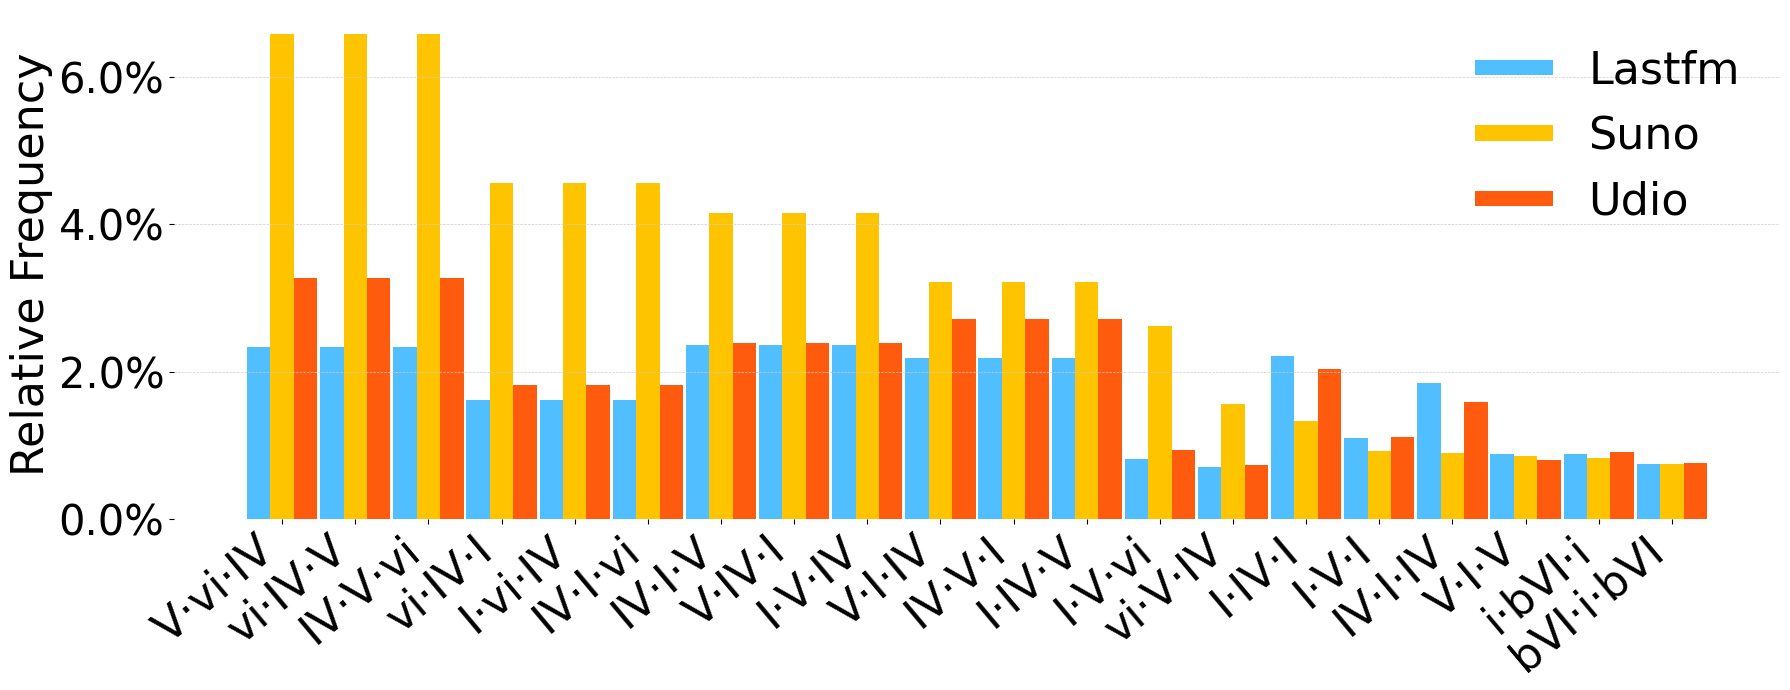

V-vi-IV (RM): Suno/Lastfm ratio: 2.83, Suno/Udio ratio: 2.01
vi-IV-V (RM): Suno/Lastfm ratio: 2.83, Suno/Udio ratio: 2.01
IV-V-vi (RM): Suno/Lastfm ratio: 2.83, Suno/Udio ratio: 2.01
vi-IV-I (RM): Suno/Lastfm ratio: 2.83, Suno/Udio ratio: 2.52
I-vi-IV: Suno/Lastfm ratio: 2.83, Suno/Udio ratio: 2.52
IV-I-vi: Suno/Lastfm ratio: 2.83, Suno/Udio ratio: 2.52
IV-I-V: Suno/Lastfm ratio: 1.76, Suno/Udio ratio: 1.73
V-IV-I: Suno/Lastfm ratio: 1.76, Suno/Udio ratio: 1.73
I-V-IV: Suno/Lastfm ratio: 1.76, Suno/Udio ratio: 1.73
V-I-IV: Suno/Lastfm ratio: 1.48, Suno/Udio ratio: 1.18
IV-V-I: Suno/Lastfm ratio: 1.48, Suno/Udio ratio: 1.18
I-IV-V: Suno/Lastfm ratio: 1.48, Suno/Udio ratio: 1.18
I-V-vi: Suno/Lastfm ratio: 3.21, Suno/Udio ratio: 2.80
vi-V-IV: Suno/Lastfm ratio: 2.21, Suno/Udio ratio: 2.13
I-IV-I: Suno/Lastfm ratio: 0.60, Suno/Udio ratio: 0.65
I-V-I: Suno/Lastfm ratio: 0.84, Suno/Udio ratio: 0.83
IV-I-IV: Suno/Lastfm ratio: 0.48, Suno/Udio ratio: 0.56
V-I-V: Suno/Lastfm ratio: 0.97, Suno/U

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

collections = ['lastfm', 'suno', 'udio']
trigram_results  = sorted(trigram_results, key=lambda d: d["suno_prop"], reverse=True)

# Prepare the data
trigram_names = [row['Trigram'].replace(' (RM)', '').replace('-', '·') for row in trigram_results]
proportions = {col: [row[f"{col}_prop"] for row in trigram_results] for col in collections}

# Bar width and positions
bar_width = 0.32
x = np.arange(len(trigram_names))

fig, ax = plt.subplots(figsize=(18, 7))
colors = ['#51BFFF', '#FFC400', '#FF5B0E']  # lastfm, suno, udio

for i, col in enumerate(collections):
    ax.bar(x + i * bar_width, proportions[col], width=bar_width, label=col.capitalize(), color=colors[i])

text_size = 32
ax.set_xticks(x + bar_width)
ax.set_xticklabels(trigram_names, rotation=40, ha='right', fontsize=text_size)
ax.set_ylabel('Relative Frequency', fontsize=text_size)
# ax.set_title('Prevalence of Canonical Pop Trigrams Across Collections', fontsize=text_size, pad=20)
ax.legend(title="", fontsize=text_size, frameon=False, handlelength=1.75, handleheight=0.15)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
ax.tick_params(axis='y', labelsize=text_size-2)

ax.grid(axis='y',                      # only horizontal lines
        linestyle='--',                # dashed
        linewidth=0.5,
        color="#cdcdcd",
        alpha=1.0) 

# Optionally annotate significant results
for i, row in enumerate(trigram_results):
    sig = (row['suno_vs_lastfm_p'] < 0.05) and (row['suno_vs_udio_p'] < 0.05)
    if sig:
        y = proportions['suno'][i]
        ax.text(x[i] + bar_width, y, '', color='gray', ha='center', fontsize=20, fontweight='bold')


for spine in ax.spines.values():
    spine.set_visible(False)
    
plt.tight_layout()
plt.show()

for row in trigram_results:
    suno_prop = row["suno_prop"]
    lastfm_prop = row["lastfm_prop"]
    udio_prop = row["udio_prop"]
    suno_vs_lastfm_ratio = suno_prop / lastfm_prop if lastfm_prop else float('inf')
    suno_vs_udio_ratio = suno_prop / udio_prop if udio_prop else float('inf')
    print(f"{row['Trigram']}: Suno/Lastfm ratio: {suno_vs_lastfm_ratio:.2f}, Suno/Udio ratio: {suno_vs_udio_ratio:.2f}")



In [22]:
for row in trigram_results:
    suno_prop = row["suno_prop"]
    lastfm_prop = row["lastfm_prop"]
    udio_prop = row["udio_prop"]
    suno_vs_lastfm_ratio = suno_prop / lastfm_prop if lastfm_prop else float('inf')
    suno_vs_udio_ratio = suno_prop / udio_prop if udio_prop else float('inf')
    p_lastfm = row.get('suno_vs_lastfm_p', float('nan'))
    p_udio = row.get('suno_vs_udio_p', float('nan'))
    print(
        f"{row['Trigram']}: "
        f"Suno/Lastfm ratio: {suno_vs_lastfm_ratio:.2f} (p={p_lastfm:.2g}), "
        f"Suno/Udio ratio: {suno_vs_udio_ratio:.2f} (p={p_udio:.2g})"
    )


V-vi-IV (RM): Suno/Lastfm ratio: 2.83 (p=0), Suno/Udio ratio: 2.01 (p=0)
vi-IV-V (RM): Suno/Lastfm ratio: 2.83 (p=0), Suno/Udio ratio: 2.01 (p=0)
IV-V-vi (RM): Suno/Lastfm ratio: 2.83 (p=0), Suno/Udio ratio: 2.01 (p=0)
vi-IV-I (RM): Suno/Lastfm ratio: 2.83 (p=0), Suno/Udio ratio: 2.52 (p=0)
I-vi-IV: Suno/Lastfm ratio: 2.83 (p=0), Suno/Udio ratio: 2.52 (p=0)
IV-I-vi: Suno/Lastfm ratio: 2.83 (p=0), Suno/Udio ratio: 2.52 (p=0)
IV-I-V: Suno/Lastfm ratio: 1.76 (p=0), Suno/Udio ratio: 1.73 (p=0)
V-IV-I: Suno/Lastfm ratio: 1.76 (p=0), Suno/Udio ratio: 1.73 (p=0)
I-V-IV: Suno/Lastfm ratio: 1.76 (p=0), Suno/Udio ratio: 1.73 (p=0)
V-I-IV: Suno/Lastfm ratio: 1.48 (p=0), Suno/Udio ratio: 1.18 (p=4.4e-105)
IV-V-I: Suno/Lastfm ratio: 1.48 (p=0), Suno/Udio ratio: 1.18 (p=4.4e-105)
I-IV-V: Suno/Lastfm ratio: 1.48 (p=0), Suno/Udio ratio: 1.18 (p=4.4e-105)
I-V-vi: Suno/Lastfm ratio: 3.21 (p=0), Suno/Udio ratio: 2.80 (p=0)
vi-V-IV: Suno/Lastfm ratio: 2.21 (p=0), Suno/Udio ratio: 2.13 (p=0)
I-IV-I: Suno/L

In [23]:
from collections import Counter
import json, pathlib

def trigram_counts(path: str):
    """
    Read one JSON trigram file and return
    (Counter{trigram -> count}, total_count)
    Normalizes minor-mode trigrams to relative major.
    """
    with open(path) as f:
        data = json.load(f)

    c = Counter()
    for row in data:                       # each row: {'ngram': [...], 'count': N}
        trigram, _ = to_relative_major(tuple(row['ngram']))
        n       = row.get('count', 1)
        c[trigram] += n
    return c, sum(c.values())

# ---- adjust the paths if yours live elsewhere ----
suno_counts,  total_suno  = trigram_counts(f"../ngram_datasets/trigrams/3gram_dataset_suno_ace{GATE_SUFFIX}.json")
last_counts,  total_last  = trigram_counts(f"../ngram_datasets/trigrams/3gram_dataset_lastfm_ace{GATE_SUFFIX}.json")

print(f"Suno trigrams loaded:  {total_suno:,}")
print(f"Last‑fm trigrams loaded: {total_last:,}")
print(f"Example Suno count for ('I','V','vi'):", suno_counts.get(('I','V','vi'), 0))

Suno trigrams loaded:  1,381,626
Last‑fm trigrams loaded: 1,393,872
Example Suno count for ('I','V','vi'): 25364


In [24]:
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import numpy as np


rows = []
for tri in trigram_targets:
    c_suno  = suno_counts.get(tri, 0)
    c_last  = last_counts.get(tri, 0)
    N_suno  = total_suno
    N_last  = total_last

    # proportions
    p_suno  = c_suno / N_suno if N_suno else 0
    p_last  = c_last / N_last if N_last else 0

    # effect size
    rr      = np.inf if p_last==0 else p_suno / p_last
    lor     = np.log2( ((c_suno+0.5)/(N_suno-c_suno+0.5)) /
                       ((c_last+0.5)/(N_last-c_last+0.5)) )

    # Fisher
    _, pval = fisher_exact([[c_suno, N_suno-c_suno],
                            [c_last, N_last-c_last]])

    rows.append((tri, c_suno, c_last, p_suno, p_last, rr, lor, pval))

df = pd.DataFrame(rows, columns=[
    'trigram','c_suno','c_last','p_suno','p_last','risk_ratio',
    'log2_odds_ratio','p'
])

# FDR correction
df['padj'] = multipletests(df['p'], method='fdr_bh')[1]

# Sort by enrichment
df = df.sort_values('risk_ratio', ascending=False)

display(df[['trigram','risk_ratio','log2_odds_ratio','padj']])


,trigram,risk_ratio,log2_odds_ratio,padj
4,"(I, V, vi)",4.262671,2.112170,0.000000e+00
1,"(vi, IV, I)",3.527452,1.848323,0.000000e+00
0,"(V, vi, IV)",3.470771,1.825518,0.000000e+00
3,"(vi, IV, V)",2.559949,1.372755,0.000000e+00
19,"(vi, V, IV)",2.479575,1.316372,0.000000e+00
5,"(IV, V, vi)",2.381822,1.267411,0.000000e+00
11,"(I, vi, IV)",2.271464,1.190796,0.000000e+00
2,"(IV, I, V)",2.260214,1.195907,0.000000e+00
14,"(IV, I, vi)",2.027900,1.026189,0.000000e+00
8,"(IV, V, I)",1.539017,0.628064,1.031368e-273


In [25]:
import numpy as np, pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# -------------------------------------------------------------
# 1 · Re‑compute the Suno‑vs‑Last‑fm stats for every trigram
# -------------------------------------------------------------
vocab = set(suno_counts) | set(last_counts)
rows  = []
for tri in vocab:
    cs = suno_counts.get(tri, 0)
    cl = last_counts.get(tri, 0)

    lor = np.log2(((cs+0.5)/(total_suno-cs+0.5)) /
                  ((cl+0.5)/(total_last-cl+0.5)))
    rr  = np.inf if cl == 0 else (cs/total_suno) / (cl/total_last)
    _, pval = fisher_exact([[cs, total_suno-cs],
                            [cl, total_last-cl]])
    rows.append((tri, cs, cl, rr, lor, pval))

df_all = pd.DataFrame(rows, columns=[
    "trigram","c_suno","c_last","risk_ratio","log2_odds_ratio","p-value"])

df_all["p-value"] = multipletests(df_all["p-value"], method="fdr_bh")[1]

# -------------------------------------------------------------
# 2 · Optionally keep only “reliable” trigrams
#     (comment these 4 lines out if you truly want *every* trigram)
# -------------------------------------------------------------
MIN_SUNO, MIN_LAST, RR_MIN, SIG = 30, 10, 2, 0.05
mask = (
    (df_all["c_suno"] >= MIN_SUNO) &
    (df_all["c_last"] >= MIN_LAST) &
    (df_all["risk_ratio"] >= RR_MIN) &
    (df_all["p-value"]     <  SIG)
)
df_hits = df_all[mask].copy()

# -------------------------------------------------------------
# 3 · Add real‑world percentages
# -------------------------------------------------------------
df_hits["% suno"] = df_hits["c_suno"] / total_suno * 100
df_hits["% last"] = df_hits["c_last"] / total_last * 100

# -------------------------------------------------------------
# 3a · Flag canonical pop progressions with an asterisk
# -------------------------------------------------------------

df_hits['trigram'] = df_hits['trigram'].apply(
    lambda tri: f"*{tri}" if tri in trigram_targets else tri
)

# -------------------------------------------------------------
# 4 · Tidy column order & display
# -------------------------------------------------------------
cols = ["trigram","c_suno","c_last","% suno","% last",
        "risk_ratio","log2_odds_ratio","p-value"]
df_hits = df_hits[cols].sort_values("risk_ratio", ascending=False)

display(df_hits.head(20))

,trigram,c_suno,c_last,% suno,% last,risk_ratio,log2_odds_ratio,p-value
5601,"(iv, ii, v)",96,10,0.006948,0.000717,9.685089,3.212960,5.898862e-18
5708,"(iii, vi, ii)",1694,202,0.122609,0.014492,8.460469,3.079158,4.316889e-294
2242,"(i, V, vi)",425,54,0.030761,0.003874,7.940129,2.977950,1.448897e-71
4872,"(v, vi, IV)",1511,192,0.109364,0.013775,7.939545,2.987161,2.221106e-254
11489,"(I, bvi, bVII)",92,13,0.006659,0.000933,7.139649,2.789308,4.837885e-15
1965,"(II, v, III)",245,35,0.017733,0.002511,7.062044,2.802783,7.669062e-39
3591,"(I, v, vi)",1227,186,0.088808,0.013344,6.655245,2.732296,4.570270e-188
3174,"(vi, iv, i)",101,18,0.007310,0.001291,5.660845,2.468700,2.076115e-14
3994,"(vi, IV, v)",928,166,0.067167,0.011909,5.639911,2.492908,2.455237e-128
51,"(bVI, iv, V)",2622,488,0.189776,0.035010,5.420574,2.439479,0.000000e+00


In [26]:
import json, numpy as np, pandas as pd
from collections import Counter
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# -------------------------------------------------------------
# 0 · Load trigram-count dictionaries for all three corpora
#     (with relative-minor normalization)
# -------------------------------------------------------------
counts, totals = {}, {}
for corpus in ["suno", "udio", "lastfm"]:
    path = f"/workspace/ngram_datasets/trigrams/3gram_dataset_{corpus}_ace{GATE_SUFFIX}.json"
    c = Counter()
    with open(path) as f:
        for entry in json.load(f):
            trigram, _ = to_relative_major(tuple(entry["ngram"]))
            c[trigram] += entry["count"]      # accumulate counts
    counts[corpus] = c
    totals[corpus] = sum(c.values())

suno_counts,  total_suno  = counts["suno"],   totals["suno"]
udio_counts,  total_udio  = counts["udio"],   totals["udio"]
last_counts,  total_last  = counts["lastfm"], totals["lastfm"]

# -------------------------------------------------------------
# 1 · Suno-vs-Last stats + capture Udio counts
# -------------------------------------------------------------
rows = []
for tri in set(suno_counts) | set(last_counts) | set(udio_counts):
    cs, cl, cu = suno_counts.get(tri, 0), last_counts.get(tri, 0), udio_counts.get(tri, 0)
    # Suno–vs–Last risk ratio (keep for sorting)
    rr = np.inf if cl == 0 else (cs / total_suno) / (cl / total_last)
    _, pval = fisher_exact([[cs, total_suno - cs],
                            [cl, total_last - cl]])
    rows.append((tri, cs, cu, cl, rr, pval))

df_all = pd.DataFrame(rows, columns=[
    "trigram", "c_suno", "c_udio", "c_last",
    "risk_ratio", "p_raw"
])
df_all["p_adj"] = multipletests(df_all["p_raw"], method="fdr_bh")[1]

# -------------------------------------------------------------
# 2 · Optional reliability filter
# -------------------------------------------------------------
MIN_SUNO, MIN_LAST, MIN_UDIO, RR_MIN, SIG = 30, 10, 10, 2, 0.05
mask = (
    (df_all["c_suno"]  >= MIN_SUNO) &
    (df_all["c_last"]  >= MIN_LAST) &
    (df_all["c_udio"]  >= MIN_UDIO) &
    (df_all["risk_ratio"] >= RR_MIN) &
    (df_all["p_adj"]      <  SIG)
)
df_hits = df_all[mask].copy()

# -------------------------------------------------------------
# 3 · Add percentages
# -------------------------------------------------------------
df_hits["% suno"] = df_hits["c_suno"] / total_suno  * 100
df_hits["% udio"] = df_hits["c_udio"] / total_udio  * 100
df_hits["% last"] = df_hits["c_last"] / total_last  * 100
sig_tris = set(df_hits["trigram"])

labels = [
    ('*' if tri in sig_tris else '') + ' · '.join(tri)
    for tri, _ in top_trigrams
]
# -------------------------------------------------------------
# 4 · Final tidy table (no log-odds or p-values)
# -------------------------------------------------------------
cols = ["trigram",
        "c_suno", 
        "c_udio", 
        "c_last", 
        "% suno",
        "% udio",
        "% last",
        "risk_ratio"]
df_final = df_hits[cols].sort_values("risk_ratio", ascending=False)

display(df_final.head(20))   # or to_csv / to_latex as you prefer

,trigram,c_suno,c_udio,c_last,% suno,% udio,% last,risk_ratio
5782,"(iv, ii, v)",96,19,10,0.006948,0.002054,0.000717,9.685089
5890,"(iii, vi, ii)",1694,280,202,0.122609,0.030265,0.014492,8.460469
2308,"(i, V, vi)",425,52,54,0.030761,0.005621,0.003874,7.940129
5025,"(v, vi, IV)",1511,124,192,0.109364,0.013403,0.013775,7.939545
11871,"(I, bvi, bVII)",92,23,13,0.006659,0.002486,0.000933,7.139649
2019,"(II, v, III)",245,32,35,0.017733,0.003459,0.002511,7.062044
3704,"(I, v, vi)",1227,145,186,0.088808,0.015673,0.013344,6.655245
3277,"(vi, iv, i)",101,23,18,0.007310,0.002486,0.001291,5.660845
4114,"(vi, IV, v)",928,148,166,0.067167,0.015997,0.011909,5.639911
56,"(bVI, iv, V)",2622,580,488,0.189776,0.062692,0.035010,5.420574


In [27]:
"""
DIAGNOSTIC: How many trigram *tokens* contain ## or # prefixed degrees?
This quantifies the key-estimation damage from ACE + _analysis.json.
"""
import json, re
from collections import Counter

_SHARP_RE = re.compile(r'^#{1,2}')          # starts with # or ##

for corpus in ("suno", "udio", "lastfm"):
    path = f"/workspace/ngram_datasets/trigrams/3gram_dataset_{corpus}_ace{GATE_SUFFIX}.json"
    clean_tokens = 0
    sharp_tokens = 0
    clean_types  = set()
    sharp_types  = set()
    with open(path) as f:
        for entry in json.load(f):
            tri = tuple(entry["ngram"])
            cnt = entry["count"]
            has_sharp = any(_SHARP_RE.search(d) for d in tri)
            if has_sharp:
                sharp_tokens += cnt
                sharp_types.add(tri)
            else:
                clean_tokens += cnt
                clean_types.add(tri)
    total = clean_tokens + sharp_tokens
    print(f"\n=== {corpus.upper()} ===")
    print(f"  Total trigram tokens : {total:>10,}")
    print(f"  Clean tokens         : {clean_tokens:>10,}  ({100*clean_tokens/total:.1f}%)")
    print(f"  #/## tokens          : {sharp_tokens:>10,}  ({100*sharp_tokens/total:.1f}%)")
    print(f"  Clean types          : {len(clean_types):>10,}")
    print(f"  #/## types           : {len(sharp_types):>10,}")

# Also check: what fraction of SONGS have at least one # degree?
import os, glob
print("\n\n=== PER-SONG KEY QUALITY (from _functional.lab files) ===")
for corpus in ("suno", "udio", "lastfm"):
    base = f"/workspace/dataset/{corpus}"
    songs_total = 0
    songs_with_sharp = 0
    for song_dir in sorted(os.listdir(base)):
        flab = os.path.join(base, song_dir, f"{song_dir}_functional.lab")
        if not os.path.isfile(flab):
            continue
        songs_total += 1
        with open(flab) as f:
            text = f.read()
        if re.search(r'##|#[IViv]', text):
            songs_with_sharp += 1
    pct = 100 * songs_with_sharp / songs_total if songs_total else 0
    print(f"  {corpus:8s}: {songs_with_sharp:>5} / {songs_total:>5} songs have # degrees ({pct:.1f}%)")



=== SUNO ===
  Total trigram tokens :  1,381,626
  Clean tokens         :  1,335,021  (96.6%)
  #/## tokens          :     46,605  (3.4%)
  Clean types          :      7,048
  #/## types           :      2,113

=== UDIO ===
  Total trigram tokens :    925,163
  Clean tokens         :    868,032  (93.8%)
  #/## tokens          :     57,131  (6.2%)
  Clean types          :      8,490
  #/## types           :      2,629

=== LASTFM ===
  Total trigram tokens :  1,393,872
  Clean tokens         :  1,304,573  (93.6%)
  #/## tokens          :     89,299  (6.4%)
  Clean types          :      8,807
  #/## types           :      2,743


=== PER-SONG KEY QUALITY (from _functional.lab files) ===
  suno    :  6398 / 18978 songs have # degrees (33.7%)
  udio    :  9850 / 19031 songs have # degrees (51.8%)
  lastfm  :  9649 / 18916 songs have # degrees (51.0%)


In [28]:
"""
DIAGNOSTIC 2: Granular breakdown — single # vs. ## vs. b-prefixed degrees
Also: where does the key come from? (_analysis.json vs. Krumhansl fallback)
"""
import json, re, os
from collections import Counter

# ------------- token-level granular breakdown ------------- 
_DOUBLE  = re.compile(r'^##')
_SINGLE  = re.compile(r'^#(?!#)')     # single # only
_FLAT    = re.compile(r'^bb')          # double flat (also an artifact)

for corpus in ("suno", "udio", "lastfm"):
    path = f"/workspace/ngram_datasets/trigrams/3gram_dataset_{corpus}_ace{GATE_SUFFIX}.json"
    buckets = Counter()
    with open(path) as f:
        for entry in json.load(f):
            tri = tuple(entry["ngram"])
            cnt = entry["count"]
            has_double = any(_DOUBLE.search(d) for d in tri)
            has_single = any(_SINGLE.search(d) for d in tri)
            has_bb     = any(_FLAT.search(d)   for d in tri)
            if has_double:
                buckets["##"] += cnt
            elif has_single:
                buckets["#"]  += cnt
            elif has_bb:
                buckets["bb"] += cnt
            else:
                buckets["clean"] += cnt
    total = sum(buckets.values())
    print(f"\n=== {corpus.upper()} ===  (token counts)")
    for k in ("clean", "#", "##", "bb"):
        n = buckets[k]
        print(f"  {k:6s}: {n:>10,}  ({100*n/total:.1f}%)")

# ------------- key source check ------------- 
print("\n\n=== KEY SOURCE PER CORPUS ===")
print("  (Does _analysis.json provide the key, or does the fallback estimator?)")
for corpus in ("suno", "udio", "lastfm"):
    base = f"/workspace/dataset/{corpus}"
    has_json_key = 0
    missing_json_key = 0
    total_checked = 0
    for song_dir in sorted(os.listdir(base)):
        analysis = os.path.join(base, song_dir, f"{song_dir}_analysis.json")
        if not os.path.isfile(analysis):
            # No analysis.json at all
            missing_json_key += 1
            total_checked += 1
            continue
        total_checked += 1
        try:
            with open(analysis) as f:
                data = json.load(f)
            ton = data.get("tonality")
            if ton and len(ton.strip().split()) >= 2:
                has_json_key += 1
            else:
                missing_json_key += 1
        except:
            missing_json_key += 1
    print(f"  {corpus:8s}: {has_json_key:>5} with JSON key / {missing_json_key:>5} fallback "
          f"(of {total_checked} songs, {100*has_json_key/total_checked:.1f}% from JSON)")


# ------------- correlation: songs with ## AND wrong key source? ------------- 
print("\n\n=== DO ##-CONTAMINATED SONGS CORRELATE WITH KEY SOURCE? ===")
for corpus in ("suno", "udio", "lastfm"):
    base = f"/workspace/dataset/{corpus}"
    json_sharp = json_clean = fb_sharp = fb_clean = 0
    for song_dir in sorted(os.listdir(base)):
        flab = os.path.join(base, song_dir, f"{song_dir}_functional.lab")
        analysis = os.path.join(base, song_dir, f"{song_dir}_analysis.json")
        if not os.path.isfile(flab):
            continue
        with open(flab) as f:
            text = f.read()
        has_double_sharp = bool(re.search(r'##', text))
        
        # Determine key source
        has_json = False
        if os.path.isfile(analysis):
            try:
                with open(analysis) as f:
                    data = json.load(f)
                ton = data.get("tonality")
                if ton and len(ton.strip().split()) >= 2:
                    has_json = True
            except:
                pass
        
        if has_json:
            if has_double_sharp:
                json_sharp += 1
            else:
                json_clean += 1
        else:
            if has_double_sharp:
                fb_sharp += 1
            else:
                fb_clean += 1
    
    total_json = json_sharp + json_clean
    total_fb   = fb_sharp + fb_clean
    print(f"\n  {corpus.upper()}:")
    if total_json:
        print(f"    JSON key : {json_sharp:>5} ## / {total_json:>5} total ({100*json_sharp/total_json:.1f}% contaminated)")
    if total_fb:
        print(f"    Fallback : {fb_sharp:>5} ## / {total_fb:>5} total ({100*fb_sharp/total_fb:.1f}% contaminated)")



=== SUNO ===  (token counts)
  clean :  1,335,021  (96.6%)
  #     :     46,605  (3.4%)
  ##    :          0  (0.0%)
  bb    :          0  (0.0%)

=== UDIO ===  (token counts)
  clean :    868,032  (93.8%)
  #     :     57,131  (6.2%)
  ##    :          0  (0.0%)
  bb    :          0  (0.0%)

=== LASTFM ===  (token counts)
  clean :  1,304,573  (93.6%)
  #     :     89,299  (6.4%)
  ##    :          0  (0.0%)
  bb    :          0  (0.0%)


=== KEY SOURCE PER CORPUS ===
  (Does _analysis.json provide the key, or does the fallback estimator?)
  suno    :     0 with JSON key / 19972 fallback (of 19972 songs, 0.0% from JSON)
  udio    :     0 with JSON key / 19992 fallback (of 19992 songs, 0.0% from JSON)
  lastfm  :     0 with JSON key / 19913 fallback (of 19913 songs, 0.0% from JSON)


=== DO ##-CONTAMINATED SONGS CORRELATE WITH KEY SOURCE? ===

  SUNO:
    Fallback :  2239 ## / 18978 total (11.8% contaminated)

  UDIO:
    Fallback :  2989 ## / 19031 total (15.7% contaminated)

  LASTF

In [29]:
import numpy as np, pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

import collections, json
from collections import Counter 

UDIO_PATH = f"../ngram_datasets/trigrams/3gram_dataset_udio_ace{GATE_SUFFIX}.json"

with open(UDIO_PATH) as f:
    data_udio = json.load(f)

udio_counts = Counter()
for row in data_udio:                 # each row: {'ngram': [...], 'count': n}
    tri, _ = to_relative_major(tuple(row['ngram']))
    udio_counts[tri] += row.get('count', 1)

total_udio = sum(udio_counts.values())
print(f"Udio trigrams loaded: {total_udio:,}")


# -------------------------------------------------------------
# 1 · Udio‑vs‑Last‑fm stats for every trigram
# -------------------------------------------------------------
vocab = set(udio_counts) | set(last_counts)
rows  = []
for tri in vocab:
    cu = udio_counts.get(tri, 0)
    cl = last_counts.get(tri, 0)

    lor = np.log2(((cu+0.5)/(total_udio-cu+0.5)) /
                  ((cl+0.5)/(total_last-cl+0.5)))
    rr  = np.inf if cl == 0 else (cu/total_udio) / (cl/total_last)
    _, pval = fisher_exact([[cu, total_udio-cu],
                            [cl, total_last-cl]])
    rows.append((tri, cu, cl, rr, lor, pval))

df_all = pd.DataFrame(rows, columns=[
    "trigram","c_udio","c_last","risk_ratio","log2_odds_ratio","p_raw"])

# FDR correction
df_all["padj"] = multipletests(df_all["p_raw"], method="fdr_bh")[1]

# -------------------------------------------------------------
# 2 · keep only reliable, enriched trigrams  (edit or comment out)
# -------------------------------------------------------------
MIN_UDIO, MIN_LAST, RR_MIN, SIG = 30, 10, 2, 0.05
mask = (
    (df_all["c_udio"]  >= MIN_UDIO) &
    (df_all["c_last"]  >= MIN_LAST) &
    (df_all["risk_ratio"] >= RR_MIN) &
    (df_all["padj"]      <  SIG)
)
df_hits = df_all[mask].copy()

# -------------------------------------------------------------
# 3 · add real‑world percentages
# -------------------------------------------------------------
df_hits["% udio"] = df_hits["c_udio"] / total_udio * 100
df_hits["% last"] = df_hits["c_last"] / total_last * 100

# -------------------------------------------------------------
# 3a · flag canonical pop progressions with an asterisk
# -------------------------------------------------------------
# Flag top Suno trigrams dynamically (uses all_target_trigrams from earlier cell)
df_hits["trigram"] = df_hits["trigram"].apply(
    lambda tri: f"*{tri}" if tri in all_target_trigrams else tri
)

# -------------------------------------------------------------
# 4 · tidy & display
# -------------------------------------------------------------
cols = ["trigram","c_udio","c_last","% udio","% last",
        "risk_ratio","log2_odds_ratio","padj"]
df_hits = df_hits[cols].sort_values("risk_ratio", ascending=False)

display(df_hits.head(20))        # change head() or drop to see more

Udio trigrams loaded: 925,163


,trigram,c_udio,c_last,% udio,% last,risk_ratio,log2_odds_ratio,padj
683,"(bvii, bIII, #iv)",32,12,0.003459,0.000861,4.017662,1.969867,3.505305e-04
10832,"(v, i, bII)",82,33,0.008863,0.002368,3.743730,1.891645,7.179147e-10
6559,"(bIII, v, #iv)",42,17,0.004540,0.001220,3.722245,1.871474,4.293534e-05
856,"(bvii, biii, bVI)",36,15,0.003891,0.001076,3.615896,1.826987,2.455479e-04
2132,"(bIII, bvii, bVI)",44,19,0.004756,0.001363,3.489022,1.781699,5.204104e-05
4837,"(IV, bii, VI)",32,14,0.003459,0.001004,3.443710,1.755741,1.118409e-03
9839,"(vi, ii, iii)",200,90,0.021618,0.006457,3.348051,1.739150,4.746561e-21
6043,"(i, #IV, ii)",31,14,0.003351,0.001004,3.336094,1.710651,1.791467e-03
621,"(ii, III, vi)",116,53,0.012538,0.003802,3.297515,1.714164,4.971945e-12
1689,"(bVII, #iv, v)",35,16,0.003783,0.001148,3.295738,1.696709,8.212443e-04


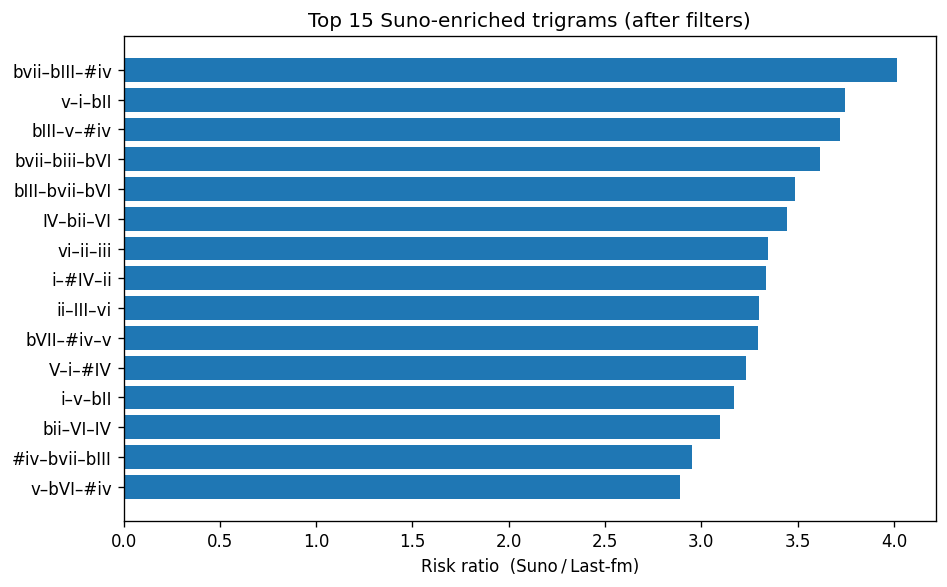

In [30]:
import matplotlib.pyplot as plt

TOP_N = 15
top15 = df_hits.head(TOP_N)

plt.figure(figsize=(8, 5), dpi=120)
plt.barh(
    ['–'.join(t) for t in top15['trigram']],   # y‑axis labels
    top15['risk_ratio']
)
plt.gca().invert_yaxis()
plt.xlabel("Risk ratio  (Suno / Last‑fm)")
plt.title(f"Top {TOP_N} Suno‑enriched trigrams (after filters)")
plt.tight_layout()
plt.show()


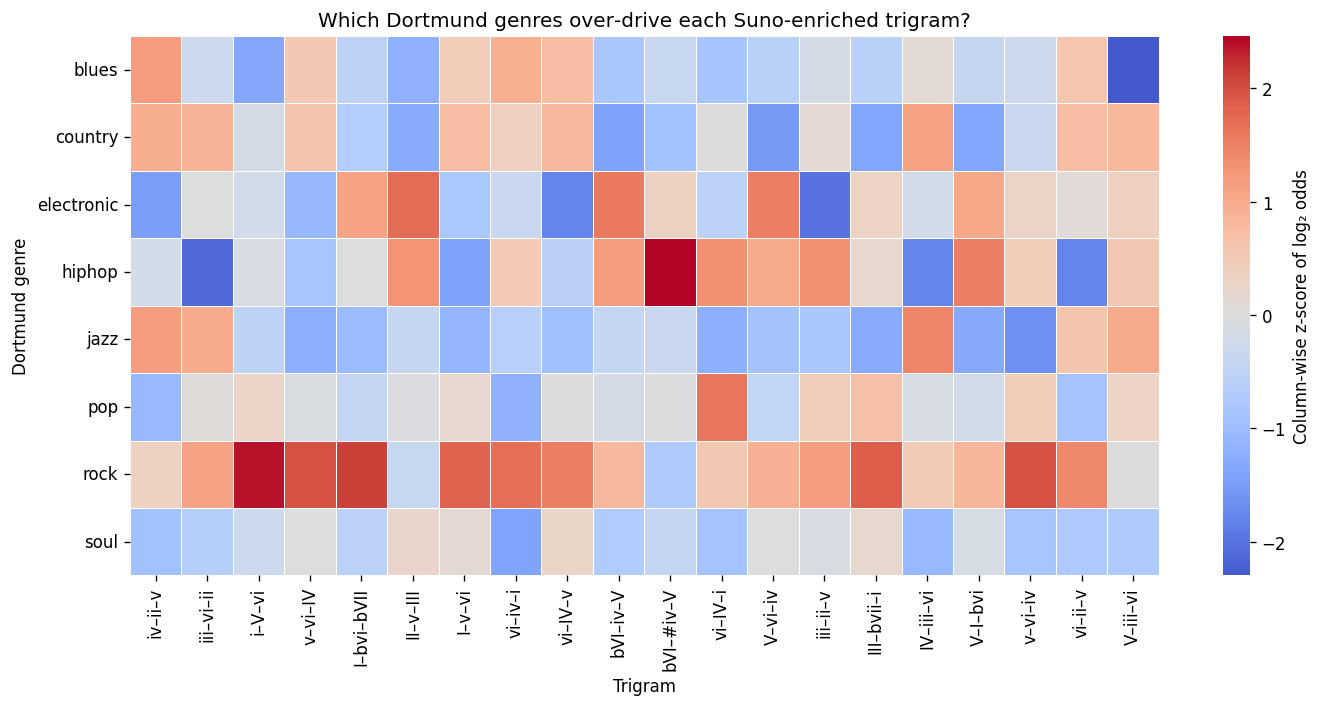

In [31]:
# ------------------------------------------------------------
# 0 · Imports
# ------------------------------------------------------------
import json, collections, numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1 · File paths
# ------------------------------------------------------------
FILES = {
    'Suno'  : f"../ngram_datasets/trigrams/3gram_dataset_suno_ace{GATE_SUFFIX}.json",
    'Udio'  : f"../ngram_datasets/trigrams/3gram_dataset_udio_ace{GATE_SUFFIX}.json",
    'Lastfm': f"../ngram_datasets/trigrams/3gram_dataset_lastfm_ace{GATE_SUFFIX}.json",
}

# ------------------------------------------------------------
# 2 · Pass 1: corpus‑level counts (for df_hits)
#     (with relative-minor normalization)
# ------------------------------------------------------------
suno_counts = collections.Counter()
last_counts = collections.Counter()
total_suno  = 0
total_last  = 0

for collection, path in FILES.items():
    with open(path) as f:
        data = json.load(f)

    for row in data:
        tri, _ = to_relative_major(tuple(row["ngram"]))
        n     = row.get("count", 1)          # integer count per corpus
        if collection == "Suno":
            suno_counts[tri] += n
            total_suno       += n
        elif collection == "Lastfm":
            last_counts[tri] += n
            total_last       += n
        # Udio is ignored for Suno‑vs‑Lastfm comparison

# ------------------------------------------------------------
# 3 · Compute enrichment table (df_hits)  ── identical logic
# ------------------------------------------------------------
vocab = set(suno_counts) | set(last_counts)
rows  = []
for tri in vocab:
    cs = suno_counts.get(tri, 0)
    cl = last_counts.get(tri, 0)

    lor = np.log2(((cs+0.5)/(total_suno-cs+0.5)) /
                  ((cl+0.5)/(total_last-cl+0.5)))
    rr  = np.inf if cl == 0 else (cs/total_suno) / (cl/total_last)
    _, pval = fisher_exact([[cs, total_suno-cs],
                            [cl, total_last-cl]])

    rows.append((tri, cs, cl, rr, lor, pval))

df_all = pd.DataFrame(rows, columns=[
    "trigram","c_suno","c_last",
    "risk_ratio","log2_odds_ratio","p"
])

df_all["padj"] = multipletests(df_all["p"], method="fdr_bh")[1]

# relevance thresholds
MIN_SUNO, MIN_LAST, RR_MIN, SIG = 30, 10, 2, 0.05
mask = (
    (df_all["c_suno"] >= MIN_SUNO) &
    (df_all["c_last"] >= MIN_LAST) &
    (df_all["risk_ratio"] >= RR_MIN) &
    (df_all["padj"] < SIG)
)
df_hits = df_all[mask].copy()

# drop the 12 canonical targets (optional)
# targets = [
#     ('I','V','vi'), ('vi','IV','I'), ('IV','I','V'), ('IV','I','v'),
#     ('IV','V','I'), ('V','I','IV'), ('VI','IV','I'), ('V','vi','IV'),
#     ('V','I','bVI'), ('IV','v','I'), ('I','v','IV'), ('ii','V','I')
# ]
# df_hits = df_hits[~df_hits["trigram"].isin(targets)]
df_hits = df_hits.sort_values("risk_ratio", ascending=False)

# add real‑world percentages
df_hits["pct_suno"] = df_hits["c_suno"] / total_suno * 100
df_hits["pct_last"] = df_hits["c_last"] / total_last * 100

# ------------------------------------------------------------
# 4 · Pass 2: genre‑level counters using DORTMUND genres only
#     (with relative-minor normalization)
# ------------------------------------------------------------
genre_coll_counters = collections.defaultdict(collections.Counter)
total_by_row        = collections.Counter()

for collection, path in FILES.items():
    with open(path) as f:
        data = json.load(f)

    for row in data:
        tri, _ = to_relative_major(tuple(row["ngram"]))
        # ---------- ONLY Dortmund genres ----------
        for genre, weight in row.get("dortmund_genres", []):
            genre = genre.lower()
            genre_coll_counters[(genre, collection)][tri] += weight
            total_by_row[(genre, collection)]             += weight
        # ------------------------------------------

# ------------------------------------------------------------
# 5 · Heat‑map of genre‑specific log‑odds ratios
# ------------------------------------------------------------
top_tris = df_hits["trigram"].head(20)      # choose how many columns to show
genres   = sorted({g for (g, coll) in genre_coll_counters
                   if coll in ("Suno", "Lastfm")})

mat = []
for g in genres:
    cs_ctr = genre_coll_counters.get((g,"Suno"),   {})
    cl_ctr = genre_coll_counters.get((g,"Lastfm"), {})
    cs_tot = total_by_row.get((g,"Suno"),   0)
    cl_tot = total_by_row.get((g,"Lastfm"), 0)
    vals = []
    for tri in top_tris:
        cs = cs_ctr.get(tri,0)
        cl = cl_ctr.get(tri,0)
        lor = np.log2(((cs+0.5)/(cs_tot-cs+0.5)) /
                      ((cl+0.5)/(cl_tot-cl+0.5)))
        vals.append(lor)
    mat.append(vals)

H = pd.DataFrame(mat, index=genres,
                 columns=["–".join(t) for t in top_tris])

# column‑wise z‑score
H_z = (H - H.mean()) / H.std(ddof=0)

plt.figure(figsize=(12,6), dpi=120)
sns.heatmap(
    H_z, cmap="coolwarm", center=0, linewidths=.5,
    cbar_kws=dict(label="Column‑wise z‑score of log₂ odds")
)
plt.title("Which Dortmund genres over‑drive each Suno‑enriched trigram?")
plt.ylabel("Dortmund genre"); plt.xlabel("Trigram")
plt.tight_layout(); plt.show()

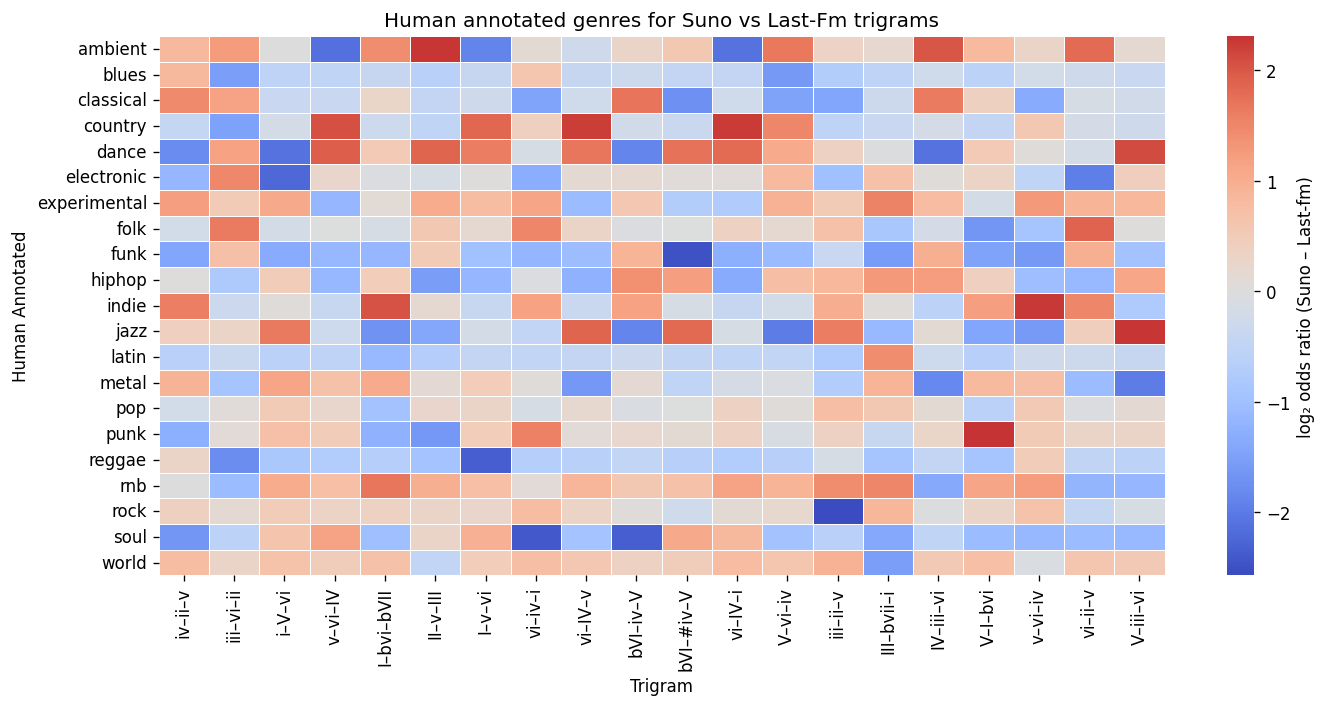

In [32]:
# -----------------------------------------------------------------
# 1 · rebuild genre_coll_counters_HUMAN (normalised)
#     (with relative-minor normalization)
# -----------------------------------------------------------------
import json, collections, numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

FILES = {
    'Suno'  : f"../ngram_datasets/trigrams/3gram_dataset_suno_ace{GATE_SUFFIX}.json",
    'Udio'  : f"../ngram_datasets/trigrams/3gram_dataset_udio_ace{GATE_SUFFIX}.json",
    'Lastfm': f"../ngram_datasets/trigrams/3gram_dataset_lastfm_ace{GATE_SUFFIX}.json",
}

genre_coll_human = collections.defaultdict(collections.Counter)
totals_human     = collections.Counter()

for collection, path in FILES.items():
    with open(path) as f:
        data = json.load(f)
    for row in data:
        tri, _ = to_relative_major(tuple(row["ngram"]))
        for style, n in row.get("human_styles", []):
            g = normalize_style(style).lower()
            genre_coll_human[(g, collection)][tri] += n
            totals_human[(g, collection)]          += n

# -----------------------------------------------------------------
# 2 · heat‑map using the SAME top_tris as before
# -----------------------------------------------------------------
top_tris = df_hits["trigram"].head(20)   # uses the df_hits you already built
genres_h = sorted({g for (g,c) in genre_coll_human if c in ("Suno","Lastfm")})

matrix = []
for g in genres_h:
    cs_ctr = genre_coll_human.get((g,'Suno'),   {})
    cl_ctr = genre_coll_human.get((g,'Lastfm'), {})
    cs_tot = totals_human.get((g,'Suno'),   0)
    cl_tot = totals_human.get((g,'Lastfm'), 0)
    vals = []
    for tri in top_tris:
        cs = cs_ctr.get(tri,0)
        cl = cl_ctr.get(tri,0)
        lor = np.log2(((cs+0.5)/(cs_tot-cs+0.5)) /
                      ((cl+0.5)/(cl_tot-cl+0.5)))
        vals.append(lor)
    matrix.append(vals)

H_human = pd.DataFrame(matrix, index=genres_h,
                       columns=["–".join(t) for t in top_tris])

# -----------------------------------------------------------------
# 3 · plot
# -----------------------------------------------------------------
plt.figure(figsize=(12,6), dpi=120)
H_z = (H_human - H_human.mean()) / H_human.std(ddof=0)
sns.heatmap(
    H_z, cmap="coolwarm", center=0, linewidths=.5,
    cbar_kws=dict(label="log₂ odds ratio (Suno – Last‑fm)")
)
plt.title("Human annotated genres for Suno vs Last-Fm trigrams")
plt.ylabel("Human Annotated"); plt.xlabel("Trigram")
plt.tight_layout(); plt.show()

In [33]:
def top_genres_for(tri, top=5):
    genre_counts = {g: ctr.get(tri,0)
                    for (g, coll), ctr in genre_coll_counters.items()
                    if coll == 'Suno'}
    return sorted(genre_counts.items(), key=lambda x:x[1], reverse=True)[:top]

for tri in df_hits['trigram'].head(10):
    print(f"\n{tri}:")
    for g, n in top_genres_for(tri):
        print(f"  {g:<12} {n}")



('iv', 'ii', 'v'):
  pop          18.81630674060002
  jazz         17.438234445999996
  rock         14.13984175290001
  country      12.121606379999996
  hiphop       11.9767303845

('iii', 'vi', 'ii'):
  jazz         355.56706352219845
  pop          339.37999152519916
  country      307.56482779749945
  rock         251.8322937429905
  electronic   111.52585038030001

('i', 'V', 'vi'):
  rock         125.293812533
  pop          77.54418946699994
  country      64.255143826
  jazz         49.080056605099934
  electronic   44.42211827486004

('v', 'vi', 'IV'):
  rock         428.2229479090795
  pop          316.34722844770005
  country      231.00705118590076
  jazz         155.80806374870087
  electronic   141.73860444545983

('I', 'bvi', 'bVII'):
  rock         52.905279640699966
  electronic   11.547640919200001
  hiphop       6.035505291370001
  jazz         5.497860134200002
  pop          4.791997540000002

('II', 'v', 'III'):
  electronic   57.658466339200096
  rock         5

In [3]:
# ============================================================
# SUNO-ENRICHED TRIGRAMS — LaTeX table for tab:suno_full_enrichment
# Uses the same 3gram_dataset_*_ace.json source as cell 26
# ============================================================

import json, numpy as np, pandas as pd
from collections import Counter
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# ── Load counts (same pipeline as cell 26); no degree exclusion ──

raw_counts, totals = {}, {}
for corpus in ["suno", "udio", "lastfm"]:
    path = f"/workspace/ngram_datasets/trigrams/3gram_dataset_{corpus}_ace{GATE_SUFFIX}.json"
    c = Counter()
    with open(path) as f:
        for entry in json.load(f):
            trigram, _ = to_relative_major(tuple(entry["ngram"]))
            c[trigram] += entry["count"]
    raw_counts[corpus] = c
    totals[corpus] = sum(c.values())

total_suno = totals["suno"]
total_udio = totals["udio"]
total_last = totals["lastfm"]

print("Trigram totals (3gram_dataset_*_ace.json):")
for corp in ["suno", "udio", "lastfm"]:
    print(f"  {corp:>8}: {totals[corp]:>10,}  ({len(raw_counts[corp]):,} unique)")

# ── Suno-vs-Lastfm enrichment (Fisher's exact + FDR) ──
rows = []
for tri in set(raw_counts["suno"]) | set(raw_counts["lastfm"]) | set(raw_counts["udio"]):
    cs = raw_counts["suno"].get(tri, 0)
    cu = raw_counts["udio"].get(tri, 0)
    cl = raw_counts["lastfm"].get(tri, 0)
    rr = np.inf if cl == 0 else (cs / total_suno) / (cl / total_last)
    _, pval = fisher_exact([[cs, total_suno - cs],
                            [cl, total_last - cl]])
    rows.append((tri, cs, cu, cl, rr, pval))

df = pd.DataFrame(rows, columns=["trigram","c_suno","c_udio","c_last","risk_ratio","p_raw"])
df["padj"] = multipletests(df["p_raw"], method="fdr_bh")[1]

# ── Filter ──
MIN_SUNO, MIN_LAST, MIN_UDIO, RR_MIN, SIG = 30, 10, 10, 2.0, 0.05
mask = (
    (df["c_suno"]     >= MIN_SUNO) &
    (df["c_last"]     >= MIN_LAST) &
    (df["c_udio"]     >= MIN_UDIO) &
    (df["risk_ratio"] >= RR_MIN)   &
    (df["padj"]       <  SIG)
)
df_hits = df[mask].copy()
df_hits["% suno"] = df_hits["c_suno"] / total_suno * 100
df_hits["% udio"] = df_hits["c_udio"] / total_udio * 100
df_hits["% last"] = df_hits["c_last"] / total_last * 100

# ── canonical pop marker '+' ──
_AXIS_POOL = {'I', 'i', 'IV', 'iv', 'V', 'v', 'vi', 'VI', 'bVI'}

def _is_canon(tri):
    return all(d in _AXIS_POOL for d in tri)

df_hits["canon"] = df_hits["trigram"].apply(_is_canon)

# ── Two-panel ranking: canonical first (by count), then others (by RR) ──
df_canon = df_hits[df_hits["canon"]].sort_values("c_suno", ascending=False)
df_other = df_hits[~df_hits["canon"]].sort_values("risk_ratio", ascending=False)

N_CANON = 15   # top canonical by count
N_OTHER = 10   # top non-canonical by risk ratio

print(f"\nSuno-enriched trigrams passing filters: {len(df_hits)}")
print(f"  canonical pop progressions (+): {len(df_canon)}")
print(f"  other enriched:                 {len(df_other)}")

print(f"\n── Panel A: Top {N_CANON} canonical axis-family progressions (by Suno count) ──")
display(df_canon[["trigram","c_suno","c_udio","c_last",
                  "% suno","% udio","% last","risk_ratio"]].head(N_CANON))

print(f"\n── Panel B: Top {N_OTHER} non-canonical enriched trigrams (by risk ratio) ──")
display(df_other[["trigram","c_suno","c_udio","c_last",
                  "% suno","% udio","% last","risk_ratio"]].head(N_OTHER))

# ── cross-check known ratios ──
print("\nCross-check (expected RR ≥ 2.5 for axis family):")
for s in ["I-V-vi","V-vi-IV","vi-IV-I","IV-I-V","vi-IV-V","V-I-bVI"]:
    tri = tuple(s.split("-"))
    row = df[df["trigram"] == tri]
    if not row.empty:
        r = row.iloc[0]
        marker = "✓ canon" if _is_canon(tri) else ""
        print(f"  {s:<12}: rr={r['risk_ratio']:.2f}  c_suno={int(r['c_suno']):,}  padj={r['padj']:.3g}  {marker}")
    else:
        print(f"  {s:<12}: not in vocabulary")

# ── LaTeX table (two-panel) ──
def _tri_label(tri, canon):
    lbl = "(" + ", ".join(tri) + ")"
    return lbl + ("$^+$" if canon else "   ")

def _fmt_c(n):
    return f"{n:,}".replace(",", r"\,")

lines = [
    r"\begin{table*}[ht]",
    r"\centering",
    r"\small",
    r"\begin{tabular}{@{}lllllllc@{}}",
    r"\toprule",
    r"Trigram & C\_Suno & C\_Udio & C\_Last & \% Suno & \% Udio & \% Last & Risk Ratio \\",
    r"\midrule",
    r"\multicolumn{8}{l}{\textit{Panel A --- Canonical axis-family progressions (sorted by frequency)}} \\[2pt]",
]
for _, row in df_canon.head(N_CANON).iterrows():
    lines.append(
        f'{_tri_label(row["trigram"], True)} & '
        f'{_fmt_c(int(row["c_suno"]))} & '
        f'{_fmt_c(int(row["c_udio"]))} & '
        f'{_fmt_c(int(row["c_last"]))} & '
        f'{row["% suno"]:.3f} & '
        f'{row["% udio"]:.3f} & '
        f'{row["% last"]:.3f} & '
        f'{row["risk_ratio"]:.2f} \\\\'
    )
lines += [
    r"\midrule",
    r"\multicolumn{8}{l}{\textit{Panel B --- Other enriched trigrams (sorted by risk ratio)}} \\[2pt]",
]
for _, row in df_other.head(N_OTHER).iterrows():
    lines.append(
        f'{_tri_label(row["trigram"], False)} & '
        f'{_fmt_c(int(row["c_suno"]))} & '
        f'{_fmt_c(int(row["c_udio"]))} & '
        f'{_fmt_c(int(row["c_last"]))} & '
        f'{row["% suno"]:.3f} & '
        f'{row["% udio"]:.3f} & '
        f'{row["% last"]:.3f} & '
        f'{row["risk_ratio"]:.2f} \\\\'
    )
lines += [
    r"\bottomrule",
    r"\end{tabular}",
    r"\caption{Suno\nobreakdash-enriched trigrams (adjusted $p < 0.05$, "
    r"risk ratio $\geq 2$). "
    r"\textit{Panel~A}: canonical axis-family progressions "
    r"(all three chords $\in \{$I, i, IV, iv, V, v, vi, VI, $\flat$VI$\}$, "
    r"marked with~$^+$), sorted by Suno count to highlight "
    r"the scale of overproduction. "
    r"\textit{Panel~B}: remaining enriched progressions, sorted by risk ratio. "
    r"C = raw count. Every row has adjusted $p < 0.001$.}",
    r"\label{tab:suno_full_enrichment}",
    r"\end{table*}",
]

print("\n" + "="*72)
print("LATEX TABLE — copy into paper_sections.tex")
print("="*72)
print("\n".join(lines))

Trigram totals (3gram_dataset_*_ace.json):
      suno:  1,381,626  (9,157 unique)
      udio:    925,163  (11,115 unique)
    lastfm:  1,393,872  (11,546 unique)



Suno-enriched trigrams passing filters: 252
  canonical pop progressions (+): 95
  other enriched:                 157

── Panel A: Top 15 canonical axis-family progressions (by Suno count) ──


,trigram,c_suno,c_udio,c_last,% suno,% udio,% last,risk_ratio
1097,"(V, vi, IV)",40007,10782,11629,2.895646,1.165416,0.834295,3.470771
6137,"(vi, IV, I)",39031,8725,11163,2.825005,0.943077,0.800863,3.527452
3715,"(IV, I, V)",32875,10697,14674,2.379443,1.156229,1.052751,2.260214
8730,"(vi, IV, V)",25877,9385,10198,1.872938,1.014416,0.731631,2.559949
7442,"(I, V, vi)",25364,4823,6003,1.835808,0.521314,0.430671,4.262671
3113,"(IV, V, vi)",25068,10078,10618,1.814384,1.089322,0.761763,2.381822
7500,"(I, vi, IV)",12318,3988,5471,0.891558,0.431059,0.392504,2.271464
5441,"(IV, I, vi)",11761,4051,5851,0.851243,0.437869,0.419766,2.027900
4764,"(vi, V, IV)",10190,2837,4146,0.737537,0.306649,0.297445,2.479575
5744,"(V, I, vi)",9768,3394,4252,0.706993,0.366854,0.305050,2.317634



── Panel B: Top 10 non-canonical enriched trigrams (by risk ratio) ──


,trigram,c_suno,c_udio,c_last,% suno,% udio,% last,risk_ratio
5076,"(iv, ii, v)",96,19,10,0.006948,0.002054,0.000717,9.685089
3346,"(iii, vi, ii)",1694,280,202,0.122609,0.030265,0.014492,8.460469
10846,"(I, bvi, bVII)",92,23,13,0.006659,0.002486,0.000933,7.139649
281,"(II, v, III)",245,32,35,0.017733,0.003459,0.002511,7.062044
10204,"(bVI, #iv, V)",398,78,75,0.028807,0.008431,0.005381,5.353702
10093,"(iii, ii, v)",79,22,16,0.005718,0.002378,0.001148,4.981263
1434,"(III, bvii, i)",270,81,55,0.019542,0.008755,0.003946,4.952602
12055,"(IV, iii, vi)",1859,462,384,0.134552,0.049937,0.027549,4.884055
693,"(V, I, bvi)",111,26,23,0.008034,0.002810,0.001650,4.868863
10144,"(vi, ii, v)",771,200,165,0.055804,0.021618,0.011838,4.714144



Cross-check (expected RR ≥ 2.5 for axis family):
  I-V-vi      : rr=4.26  c_suno=25,364  padj=0  ✓ canon
  V-vi-IV     : rr=3.47  c_suno=40,007  padj=0  ✓ canon
  vi-IV-I     : rr=3.53  c_suno=39,031  padj=0  ✓ canon
  IV-I-V      : rr=2.26  c_suno=32,875  padj=0  ✓ canon
  vi-IV-V     : rr=2.56  c_suno=25,877  padj=0  ✓ canon
  V-I-bVI     : rr=1.86  c_suno=2,123  padj=1.18e-65  ✓ canon

LATEX TABLE — copy into paper_sections.tex
\begin{table*}[ht]
\centering
\small
\begin{tabular}{@{}lllllllc@{}}
\toprule
Trigram & C\_Suno & C\_Udio & C\_Last & \% Suno & \% Udio & \% Last & Risk Ratio \\
\midrule
\multicolumn{8}{l}{\textit{Panel A --- Canonical axis-family progressions (sorted by frequency)}} \\[2pt]
(V, vi, IV)$^+$ & 40\,007 & 10\,782 & 11\,629 & 2.896 & 1.165 & 0.834 & 3.47 \\
(vi, IV, I)$^+$ & 39\,031 & 8\,725 & 11\,163 & 2.825 & 0.943 & 0.801 & 3.53 \\
(IV, I, V)$^+$ & 32\,875 & 10\,697 & 14\,674 & 2.379 & 1.156 & 1.053 & 2.26 \\
(vi, IV, V)$^+$ & 25\,877 & 9\,385 & 10\,198 & 1.

In [2]:
# ============================================================
# CROSS-COLLECTION TRIGRAM CORRELATIONS (full vocabulary)
# Mirrors 07_replication_tetragrams_ACE.ipynb cell 8: Pearson r over the
# union of trigram types, raw counts, on the gate_false dataset JSONs.
# Values quoted in the paper (Section 6.2): L-U 0.981, L-S 0.795, S-U 0.861
# ============================================================
import json
import numpy as np
from collections import Counter

tri = {}
for corpus in ["lastfm", "suno", "udio"]:
    c = Counter()
    with open(f"/workspace/ngram_datasets/trigrams/3gram_dataset_{corpus}_ace{GATE_SUFFIX}.json") as f:
        for entry in json.load(f):
            c[tuple(entry["ngram"])] += entry["count"]
    tri[corpus] = c

def corr(a, b):
    keys = set(tri[a]) | set(tri[b])
    va = np.array([tri[a].get(k, 0) for k in keys])
    vb = np.array([tri[b].get(k, 0) for k in keys])
    return float(np.corrcoef(va, vb)[0, 1])

for pair in [("lastfm", "udio"), ("lastfm", "suno"), ("suno", "udio")]:
    print(f"{pair[0]}-{pair[1]}: r = {corr(*pair):.3f}")


lastfm-udio: r = 0.981
lastfm-suno: r = 0.795
suno-udio: r = 0.861
